# Quantum Computing for Quantum Chemistry

This laboratory follows the Quantum Computing for Quantum Chemistry manual [1].

Import libraries

In [1]:
import numpy as np
from pyscf import gto
from openfermion import FermionOperator as FO
from pyscf import scf, fci
from IPython.display import Image
from openfermionpyscf import run_pyscf
from openfermion import MolecularData, get_fermion_operator
from openfermion import QubitOperator as ofQubitOperator
from openfermion.transforms import jordan_wigner
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit import QuantumCircuit
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit_aer import AerSimulator
import matplotlib.pyplot as plt
from qiskit.quantum_info import Statevector
from qiskit import QuantumRegister, ClassicalRegister
from qiskit.circuit.library import QFTGate
from qiskit import transpile
import time

# Part I
## Conventional quantum chemistry

#### First-quantised Hamiltonians and wavefunctions

Under the Born-Oppenheimer approximation (fixed nuclei), the electronic Hamiltonian for $N$ electrons and $N_n$ nuclei is
$$
\hat H=\hat h+\hat g+v_{nn}.
$$
The one-electron (core) term is
$$
\hat h=\sum_{i=1}^{N}\left(-\frac12\nabla_i^2-\sum_{A=1}^{N_n}\frac{Z_A}{|\mathbf r_i-\mathbf R_A|}\right),
$$
with $\mathbf{r}_i$ spatial coordinates of the $i^{\text{th}}$ electron and $\mathbf{R}_A$ the spatial coordinates of the $A^{\text{th}}$ nucleus with atomic number $Z_A$. The two-electron repulsion is
$$
\hat g=\frac12\sum_{i=1}^{N}\sum_{j\neq i}^{N}\frac{1}{|\mathbf r_i-\mathbf r_j|},
$$
and the nucleus-nucleus repulsion is the constant
$$
v_{nn}=\frac12\sum_{A=1}^{N_n}\sum_{B\neq A}^{N_n}\frac{Z_AZ_B}{|\mathbf R_A-\mathbf R_B|}.
$$
The electronic Schrödinger equation is solved,
$$
\hat H\Psi_j = E_j\Psi_j\quad j=0,1,2,\dots,
$$
where $\Psi_j(\mathbf x_1,\dots,\mathbf x_N)$ is an $N$-electron wavefunction with $\mathbf x_i=(\mathbf r_i,s_i)$ denoting the spatial and spin coordinates of electron $i$ [1].


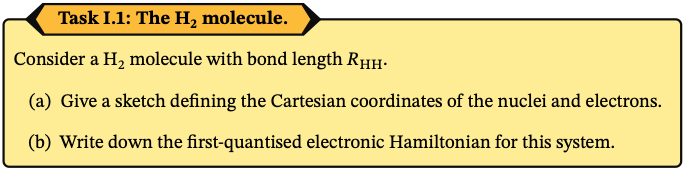

In [2]:
Image('1_1.png')

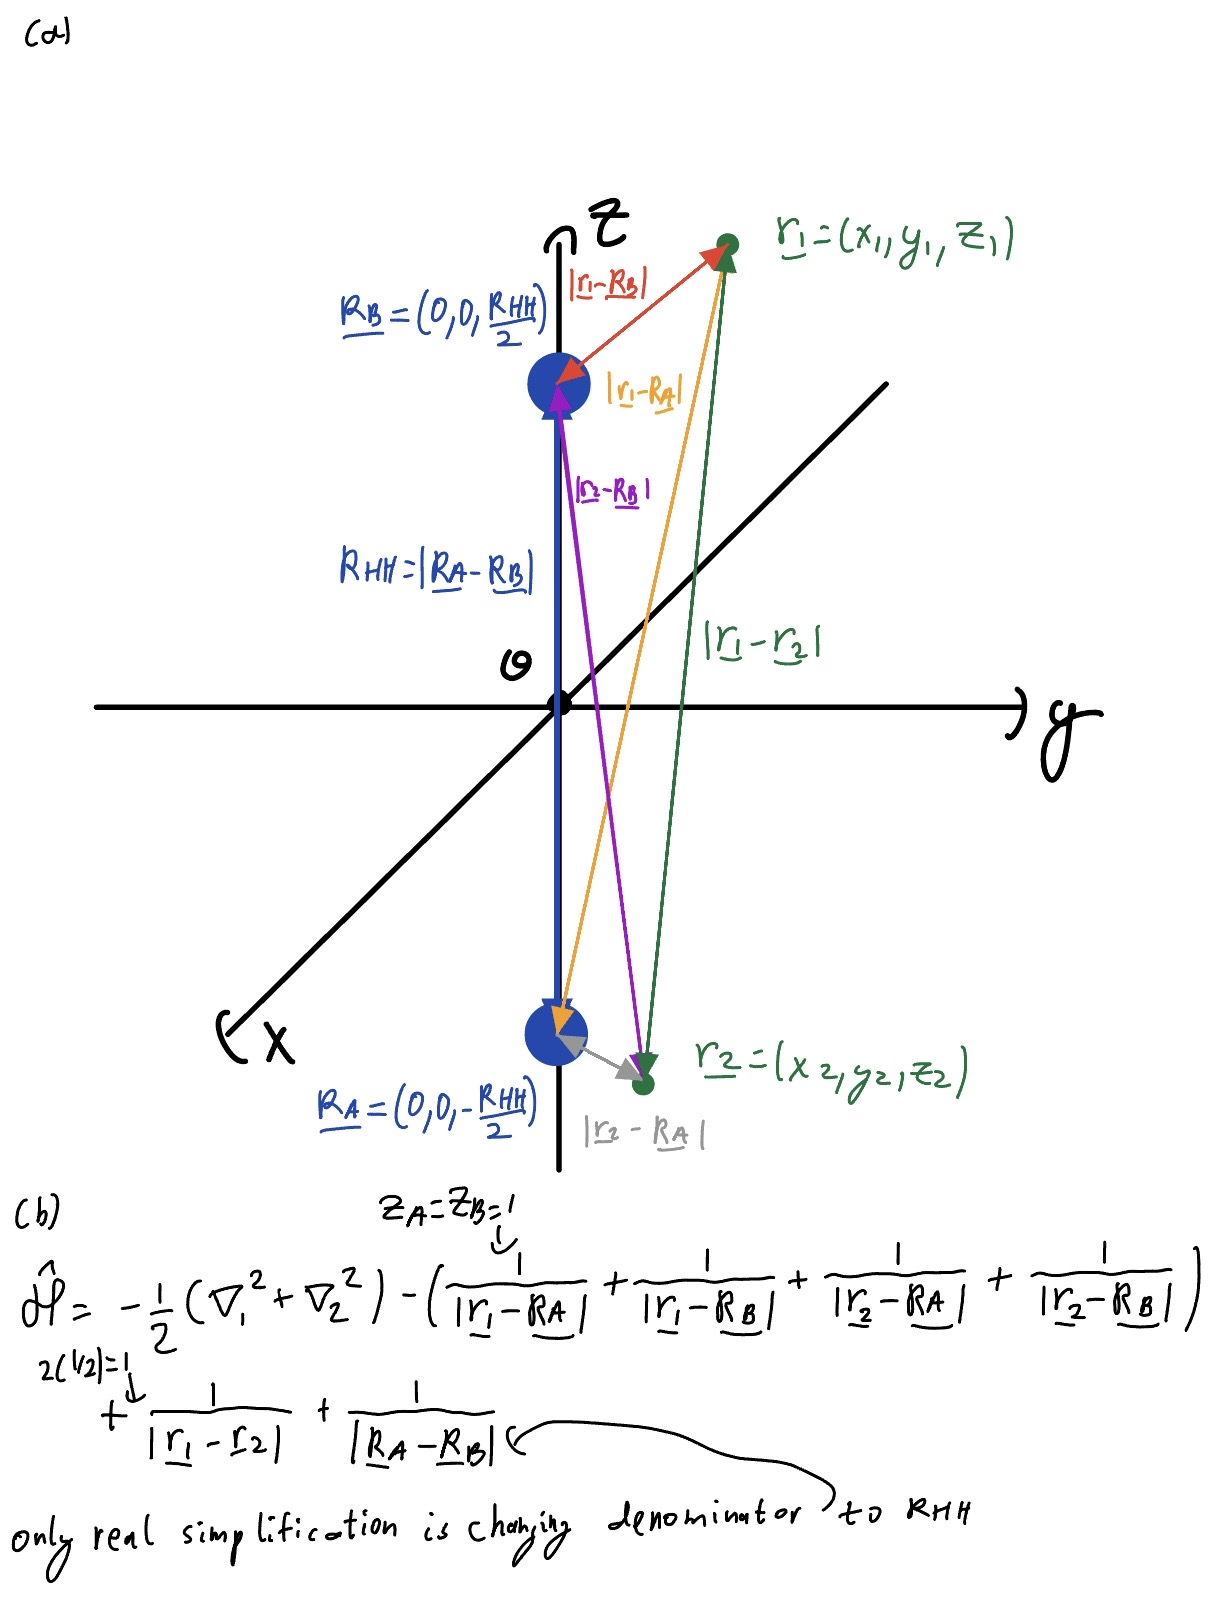

In [3]:
Image('1_1_a.jpg')

#### Introducing an atomic-orbital basis set

The coordinate representation of $\hat H$ and $\Psi$ is typically replaced by a basis-set representation to enable standard linear-algebra methods. For molecules, an atomic-orbital (AO) Gaussian basis $\{\phi_\mu(\mathbf r)\}$ is used, with each function centred on a nucleus.

The one-electron operator is represented by the core Hamiltonian matrix $h$ with elements
$$
h_{\mu\nu}=\int \phi_\mu^*(\mathbf r)\hat h_1(\mathbf r)\phi_\nu(\mathbf r)d\mathbf r
\equiv \langle \mu|\hat h_1|\nu\rangle_{\mathbf r}.
\tag{1}
$$
The two-electron operator is represented by the electron repulsion integral (ERI) tensor $g$ with elements
$$
g_{\mu\nu\mu'\nu'}
=\iint \phi_\mu^*(\mathbf r_1)\phi_\nu^*(\mathbf r_2)\hat g_{12}(\mathbf r_1,\mathbf r_2)\phi_{\mu'}(\mathbf r_1)\phi_{\nu'}(\mathbf r_2)d\mathbf r_1d\mathbf r_2
\equiv (\mu\mu'|\nu\nu')_{\mathbf r_1\mathbf r_2},
\tag{2}
$$
with $\hat g_{12}(\mathbf r_1,\mathbf r_2)=1/r_{12}=1/|\mathbf r_1-\mathbf r_2|$, and using chemists' notation [1].

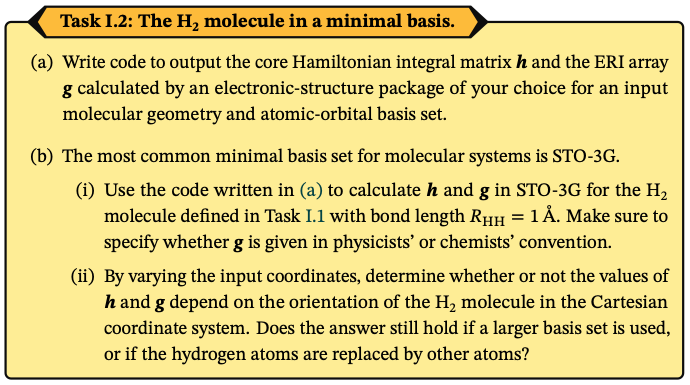

In [4]:
Image('1_2.png')

**(a)**

In [5]:
def core_and_eri(atom,basis="sto-3g",unit="Angstrom",charge= 0,spin=0):
    
    mol = gto.Mole()
    mol.atom = atom
    mol.unit = unit
    mol.basis = basis
    mol.charge = charge 
    mol.spin = spin
    mol.build()

    # Core Hamiltonian
    h = mol.intor("int1e_kin") + mol.intor("int1e_nuc") #one electron AO integrals

    # PySCF defaults to chemists' notation
    g = mol.intor("int2e")
    v = mol.energy_nuc()#needed later
    return h,g,v

**(b)**

**(i)**

STO-3G is a minimal basis set where each basis function is a contracted Gaussian made from three Gaussians, fitted to approximate a Slater type orbital. In a minimal basis, one contracted function is used for each occupied atomic orbital of the free atom [2]. For $H$ each atom has only $1s$ occupied, so you get one contracted $1s$ function per $H$.

PySCF has $g_{\mu\mu'\nu\nu'}=(\mu\mu'|\nu\nu')$ [3].

In [6]:
atom = """
H 0 0 0
H 0 0 1
"""
# first is H at origin, second is H at (0,0,1)

print("Chemists' convention")
h,g,v=core_and_eri(atom=atom)
print("\nh =",h)
print("g =",g)

Chemists' convention

h = [[-0.97949638 -0.68286493]
 [-0.68286493 -0.97949638]]
g = [[[[0.77460594 0.30930897]
   [0.30930897 0.47804137]]

  [[0.30930897 0.15786578]
   [0.15786578 0.30930897]]]


 [[[0.30930897 0.15786578]
   [0.15786578 0.30930897]]

  [[0.47804137 0.30930897]
   [0.30930897 0.77460594]]]]


One electron energy in AO $1s$ on each $H$.
$$
h_{11}=( 1|\hat h|1)_\mathbf{r}
=-0.9794963769
$$

Coupling between the two AOs. 
$$
h_{12}=( 1|\hat h|2)_\mathbf{r}
=-0.6828649331
$$

Coulomb repulsion for two electrons in AO 1 (opposite spins).
$$
g_{1111}=(11|11)_{\mathbf{r}_1\mathbf{r}_2}=0.7746059439
$$

Coulomb repulsion between the overlap densities.
$$
g_{1212}=(12|12)_{\mathbf{r}_1\mathbf{r}_2}=0.1578657779
$$

Coulomb interaction between densities on different atoms.
$$
g_{1122}=(11|22)_{\mathbf{r}_1\mathbf{r}_2}=0.4780413732
$$

Exchange interaction.
$$
g_{1221}=(12|21)_{\mathbf{r}_1\mathbf{r}_2}=0.1578657779
$$

Repulsion between the density on atom 1 and the overlap density.
$$
g_{1112}=(11|12)_{\mathbf{r}_1\mathbf{r}_2}=0.3093089672
$$

**(ii)**

1. Along $z-$axis, centre at origin.

In [7]:
atom = """
H 0 0 -0.5
H 0 0 0.5
"""

h,g,v=core_and_eri(atom=atom)
print("h =",h)
print("g =",g)


h = [[-0.97949638 -0.68286493]
 [-0.68286493 -0.97949638]]
g = [[[[0.77460594 0.30930897]
   [0.30930897 0.47804137]]

  [[0.30930897 0.15786578]
   [0.15786578 0.30930897]]]


 [[[0.30930897 0.15786578]
   [0.15786578 0.30930897]]

  [[0.47804137 0.30930897]
   [0.30930897 0.77460594]]]]


Along $y-$axis, with $z=1$.

In [8]:
atom = """
H 0 1 1
H 0 0 1
"""
h,g,v=core_and_eri(atom=atom)
print("h =",h)
print("g =",g)


h = [[-0.97949638 -0.68286493]
 [-0.68286493 -0.97949638]]
g = [[[[0.77460594 0.30930897]
   [0.30930897 0.47804137]]

  [[0.30930897 0.15786578]
   [0.15786578 0.30930897]]]


 [[[0.30930897 0.15786578]
   [0.15786578 0.30930897]]

  [[0.47804137 0.30930897]
   [0.30930897 0.77460594]]]]


$45$ degrees in the $xy-$plane.

In [9]:
atom = """
H -0.353553 -0.353553 0
H  0.353553  0.353553 0
"""
h,g,v=core_and_eri(atom=atom)
print("h =",h)
print("g =",g)

h = [[-0.97949687 -0.68286598]
 [-0.68286598 -0.97949687]]
g = [[[[0.77460594 0.30930948]
   [0.30930948 0.47804173]]

  [[0.30930948 0.15786624]
   [0.15786624 0.30930948]]]


 [[[0.30930948 0.15786624]
   [0.15786624 0.30930948]]

  [[0.47804173 0.30930948]
   [0.30930948 0.77460594]]]]


Small differences due to numerical roundoff.

Along $(1,1,1)$ direction

In [10]:
atom = """
H -0.288675 -0.288675 -0.288675
H  0.288675  0.288675  0.288675
"""
h,g,v=core_and_eri(atom=atom)
print("h =",h)
print("g =",g)

h = [[-0.97949659 -0.68286537]
 [-0.68286537 -0.97949659]]
g = [[[[0.77460594 0.30930918]
   [0.30930918 0.47804153]]

  [[0.30930918 0.15786597]
   [0.15786597 0.30930918]]]


 [[[0.30930918 0.15786597]
   [0.15786597 0.30930918]]

  [[0.47804153 0.30930918]
   [0.30930918 0.77460594]]]]


The electronic Hamiltonian is invariant under rigid rotations, so any observable is independent of the molecule’s absolute orientation, but, the AO integral tensors $h_{pq}$ and $g_{pqrs}$ are basis dependent. If the chosen AO basis **contains** $l>0$ **functions** (even if the occupied atomic orbitals are $s-$type), a rigid rotation mixes AOs within each angular momentum shell, so the rotated integrals are generally not equal elementwise, but are related by the corresponding AO rotation within each shell.

$H_2$ is invariant here because the chosen basis is effectively $s-$only, so rotation doesn’t mix AOs.

Consider $\text{Li}_2$, $\text{Li}$’s occupied orbitals have $l=0$ (including an occupied $2s$ valence orbital), and since $2s$ and $2p$ orbitals share the same exponents, the **basis** contains $l>0$ ($p$) functions [4]. Since the chosen basis includes $p$ functions, the rotation mixes ($p_x,p_y,p_z$) and changes $h,g$ elementwise. Let's verify this.

Start with the first $\text{Li}$ at the origin, and the second along the $z-$axis up to $z=1$.

In [11]:
atom = """
Li 0 0 0
Li 0 0 1
"""
h,g,v=core_and_eri(atom=atom)
print("h =",h)
print("g =",g)

h = [[-5.99338978 -1.363622    0.          0.         -0.11716946 -0.65837286
  -1.25509831  0.          0.          1.85815807]
 [-1.363622   -2.17419742  0.          0.         -0.42176859 -1.25509831
  -2.00608196  0.          0.          1.06224229]
 [ 0.          0.         -1.83933536  0.          0.          0.
   0.         -1.52706153  0.          0.        ]
 [ 0.          0.          0.         -1.83933536  0.          0.
   0.          0.         -1.52706153  0.        ]
 [-0.11716946 -0.42176859  0.          0.         -2.16072041 -1.85815807
  -1.06224229  0.          0.         -0.68048311]
 [-0.65837286 -1.25509831  0.          0.         -1.85815807 -5.99338978
  -1.363622    0.          0.          0.11716946]
 [-1.25509831 -2.00608196  0.          0.         -1.06224229 -1.363622
  -2.17419742  0.          0.          0.42176859]
 [ 0.          0.         -1.52706153  0.          0.          0.
   0.         -1.83933536  0.          0.        ]
 [ 0.          0.     

$45$ degrees in the $xy-$plane.

In [12]:
atom = """
Li -0.353553 -0.353553 0
Li  0.353553  0.353553 0
"""
h,g,v=core_and_eri(atom=atom)
print("h =",h)
print("g =",g)

h = [[-5.99339153 -1.36362239 -0.08285147 -0.08285147  0.         -0.6583758
  -1.25509921  1.31391678  1.31391678  0.        ]
 [-1.36362239 -2.17419775 -0.29823541 -0.29823541  0.         -1.25509921
  -2.00608264  0.75111831  0.75111831  0.        ]
 [-0.08285147 -0.29823541 -2.0000282  -0.16069247  0.         -1.31391678
  -0.75111831 -1.10377378  0.42328868  0.        ]
 [-0.08285147 -0.29823541 -0.16069247 -2.0000282   0.         -1.31391678
  -0.75111831  0.42328868 -1.10377378  0.        ]
 [ 0.          0.          0.          0.         -1.83933573  0.
   0.          0.          0.         -1.52706246]
 [-0.6583758  -1.25509921 -1.31391678 -1.31391678  0.         -5.99339153
  -1.36362239  0.08285147  0.08285147  0.        ]
 [-1.25509921 -2.00608264 -0.75111831 -0.75111831  0.         -1.36362239
  -2.17419775  0.29823541  0.29823541  0.        ]
 [ 1.31391678  0.75111831 -1.10377378  0.42328868  0.          0.08285147
   0.29823541 -2.0000282  -0.16069247  0.        ]
 [ 1.

As expected, both are different. The size of $h$ is $10\times 10$, i.e. 10 spatial AOs in total, or 5 per $\text{Li}$. This indicates that the basis includes $p$ functions, with each $\text{Li}$ contributing one $s$ function for $1s$, one $s$ function for $2s$, and three $p$ functions ($2p_x,2p_y,2p_z$).

#### Second quantisation

For quantum-computing treatments of electronic structure, the coordinate representation is replaced by second quantisation, where the Hamiltonian and states are expressed using discrete fermionic creation and annihilation operators. This naturally enforces antisymmetry and provides a direct encoding in an occupation-number basis.

Given $M$ orthonormal spin-orbitals $\{\chi_p(\mathbf x)\}_{p=0}^{M-1}$ with $\mathbf x=(\mathbf r,s)$, an $N$-electron configuration is represented by an occupation vector
$$
|\mathbf k\rangle = |k_0,k_1,\dots,k_{M-1}\rangle,\qquad k_p\in\{0,1\}.
$$

The elementary fermionic operators change the occupation of a given spin-orbital, with the fermionic phase factor $\Gamma_p^\mathbf{k}=\prod_{q=0}^{p-1}\left(-1\right)^{k_q}$ [1],
$$
\hat a_p^\dagger|\dots,k_p,\dots\rangle = \delta_{k_p,0}\Gamma_p^\mathbf{k}|\dots,1,\dots\rangle,
$$
$$
\hat a_p|\dots,k_p,\dots\rangle = \delta_{k_p,1}\Gamma_p^\mathbf{k}|\dots,0,\dots\rangle.
$$

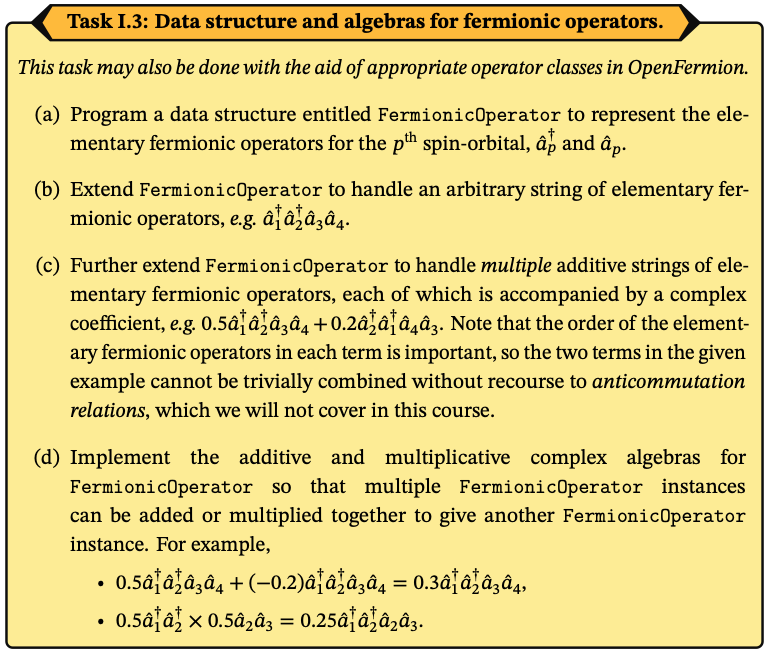

In [13]:
Image('1_3.png')

In [14]:
class FermionicOperator:
    def __init__(self, _of=None):
        self._of = _of if _of is not None else FO() 
#stores operator, if empty allows zero operator
    
#(a)
    @staticmethod #(does not use self)
    def create(i):
        return FermionicOperator(FO(((int(i), 1),), 1.0)) #create at site i (coeff of 1)
#((int(i), 1),) is a one-element tuple holding (int(i), 1)  
    @staticmethod
    def destroy(i):
        return FermionicOperator(FO(((int(i), 0),), 1.0))
        
#(b)
    @staticmethod
    def string(ops, coeff=1.0):
        term = tuple((int(i),ca) for i, ca in ops)
#ops is an ordered list of (i, ca), ca is create/annihilate (1 or 0 respectively)
        return FermionicOperator(FO(term, complex(coeff)))

#(c)
    @staticmethod
    def sum(terms):
        of = FO()
        for coeff, ops in terms:
            of += FermionicOperator.string(ops, coeff)._of #unwraps to get FO
        return FermionicOperator(of)
#(d)
# __add__ adds two FO objects,
    def __add__(self, other):
        return FermionicOperator(self._of + other._of)

    def __mul__(self, other):
        if isinstance(other, FermionicOperator):
# if other is a fermionic operator, do operator multiplication, otherwise do scalar multiplication
            return FermionicOperator(self._of * other._of)
        return FermionicOperator(self._of * complex(other))

    def __rmul__(self, other):
        return FermionicOperator(complex(other) * self._of)

    def __str__(self):
        #useful for II.3 part (d), prints string of object
        return str(self._of)
    

    
    def to_openfermion(self):
        return self._of
#returns operator

Sum and Add do the same thing in slightly different ways which is shown below, Sum reads slightly cleaner, but Add follows the task closer, so I have included both.

Verify that $0.5\hat{a}_1^\dagger\hat{a}_2^\dagger\hat{a}_3\hat{a}_4+(-0.2)\hat{a}_1^\dagger\hat{a}_2^\dagger\hat{a}_3\hat{a}_4=0.3\hat{a}_1^\dagger\hat{a}_2^\dagger\hat{a}_3\hat{a}_4$.

In [15]:
expr1 = FermionicOperator.sum([
    (0.5, [(1,1), (2,1), (3,0), (4,0)]),
    (-0.2, [(1,1), (2,1), (3,0), (4,0)])
])
print('Using Sum, expression becomes',expr1.to_openfermion())

expr2 = (FermionicOperator.string([(1,1), (2,1), (3,0), (4,0)], 0.5)
         + FermionicOperator.string([(1,1), (2,1), (3,0), (4,0)], -0.2))
print('\nUsing Add, expression becomes',expr2.to_openfermion())

Using Sum, expression becomes (0.3+0j) [1^ 2^ 3 4]

Using Add, expression becomes (0.3+0j) [1^ 2^ 3 4]


Verify that $0.5\hat{a}_1^\dagger\hat{a}_2^\dagger\times0.5\hat{a}_2\hat{a}_3=0.25\hat{a}_1^\dagger\hat{a}_2^\dagger\hat{a}_2\hat{a}_3$

In [16]:
expr3 = (FermionicOperator.string([(1,1), (2,1)], 0.5)
         * FermionicOperator.string([(2,0), (3,0)], 0.5))
print('Expression becomes',expr3.to_openfermion())

Expression becomes (0.25+0j) [1^ 2^ 2 3]


## Module 1 Logbook 

The laboratory introduced the electronic Hamiltonian for an $N$ electron system with $N_n$ fixed nuclei, written as $\hat{\mathcal{H}}=\hat{h}+\hat{g}+v_{nn}$, where $\hat{h}$ is the one-electron term, $\hat{g}$ the two-electron interaction, and $v_{nn}$ the nucleus-nucleus repulsion. The coordinate representation was introduced first, then the Hamiltonian was expressed in an AO basis through the integrals $h_{\mu\nu}=\langle\mu|\hat{h}_1|\nu\rangle_\mathbf{r}$ and $g_{\mu\mu'\nu\nu'}=(\mu\mu'|\nu\nu')$ used in practical calculations. For $H_2$ with bond length $R_{HH}=1$ Angstrom in the STO-3G minimal basis, the core Hamiltonian integral matrix $\mathbf{h}$ and the electron repulsion integral array $\mathbf{g}$ were generated using PySCF. STO-3G is a minimal Gaussian basis set in which each basis function is formed by contracting three Gaussian primitives to approximate a Slater-type orbital. In a minimal basis, it assigns a single contracted function to each occupied atomic orbital of the isolated atom [2]. The output convention for $\mathbf{g}$ was the chemists' convention $g_{\mu\mu'\nu\nu'}=(\mu\mu'|\nu\nu')$.

Orientation tests agree with theory. For $H_2$, $\mathbf h$ and $\mathbf g$ are unchanged under rigid rotations and translations, as expected when the AO basis is effectively $s$ only. While physical observables are rotation invariant, AO integrals are only elementwise invariant when the basis contains no $l>0$ functions. Once $p$ (or higher) functions are present, a rigid rotation mixes $(p_x,p_y,p_z)$ within each atom’s shell, so $h_{pq}$ and $g_{pqrs}$ generally change elementwise, as seen in the $\text{Li}_2$ check.

Second quantisation was then introduced, treating electrons as excitations in a spin-orbital basis, which simplifies many-body problems. Instead of working with continuous coordinates, the system is described in a discrete set of spin orbitals using fermionic creation and annihilation operators. The occupation number picture makes the state space explicit, and the fermionic operator algebra automatically enforces antisymmetry. A FermionicOperator data structure was implemented to represent these creation and annihilation operators, ordered strings of operators, and sums of these strings with complex coefficients.

Correctness was checked in two ways. The additive and multiplicative examples provided in the laboratory book were reproduced, confirming that identical strings combined by coefficient addition and that multiplication produced the expected coefficient product with the operator strings concatenated in the correct order. For the integral generation, the rotation invariance test confirmed that the geometry, units, and integral calls were consistent.

# Part II
## Towards Quantum Computing

The occupation-number state $|\mathbf k\rangle$ is generated from the vacuum by [1]
$$|\mathbf{k}\rangle=\left[\prod_{p=0}^{M-1} \left(\hat{a}_p^\dagger\right)^{k_p}\right]|\text{vac}\rangle=\left(\hat{a}_0^\dagger\right)^{k_0}\left(\hat{a}_1^\dagger\right)^{k_1}\cdots\left(\hat{a}_{M-1}^\dagger\right)^{k_{M-1}}|0,0,\cdots,0\rangle$$
$$
=\begin{cases}\left(\hat{a}_{M-1}^\dagger\right)^{1}|0,0,\cdots,0\rangle=|0,0,\cdots,0,1\rangle,& k_0=\cdots =k_{M-2}=0,k_{M-1}=1\\|0,0,\cdots,0\rangle,& k_0=\cdots= k_{M-1}=0.\end{cases}$$
For fermions, a fixed mode ordering is applied to avoid sign ambiguities, the product then acts on $|\text{vac}\rangle$ from right to left.

Note that until stated otherwise, the convention that the leftmost bit corresponds to qubit $0$ will be used, as in the manual.

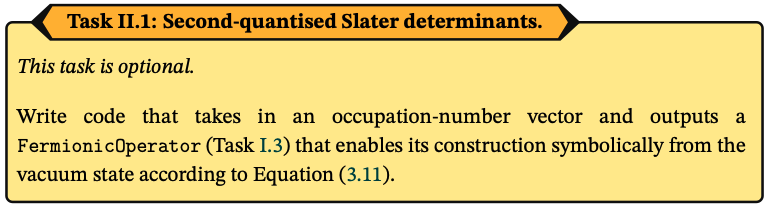

In [17]:
Image('2_1.png')

In [18]:
def occupation_to_operator(k):
    ops = [(i, 1) for i, occ in enumerate(k) if occ] #(i,1) for every occ=1
    return FermionicOperator.string(ops, 1.0)

In [19]:
k1 = (1,0,1,0)
op = occupation_to_operator(k1)
print('k1 =',op.to_openfermion())            


k2 = (0,1,1,0,1)
op2 = occupation_to_operator(k2)
print('k2 =',op2.to_openfermion())          

k1 = (1+0j) [0^ 2^]
k2 = (1+0j) [1^ 2^ 4^]


The electronic Hamiltonian is written in second quantisation as
$$
\hat H=\sum_{pq}^{M-1} h_{pq}\hat a_p^\dagger \hat a_q
+\frac12\sum_{pqrs}^{M-1} g_{pqrs}\hat a_p^\dagger \hat a_r^\dagger \hat a_s \hat a_q
+v_{nn},
$$
where the one- and two-electron integrals are
$$
h_{pq}=\int \chi_p^*(\mathbf x)\hat h_1(\mathbf r)\chi_q(\mathbf x)d\mathbf x,
\quad
g_{pqrs}=\iint \chi_p^*(\mathbf x_1)\chi_q^*(\mathbf x_2)\hat g_{12}(\mathbf r_1,\mathbf r_2)\chi_r(\mathbf x_1)\chi_s(\mathbf x_2)d\mathbf x_1d\mathbf x_2.
$$
Unlike the integrals in $(1)$ and $(2)$, these involve integration over both spatial and spin coordinates, rather than only involving spatial coordinates [1].

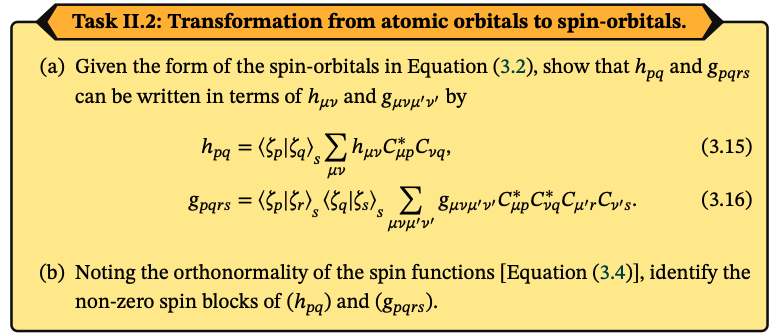

In [20]:
Image('2_2.png')

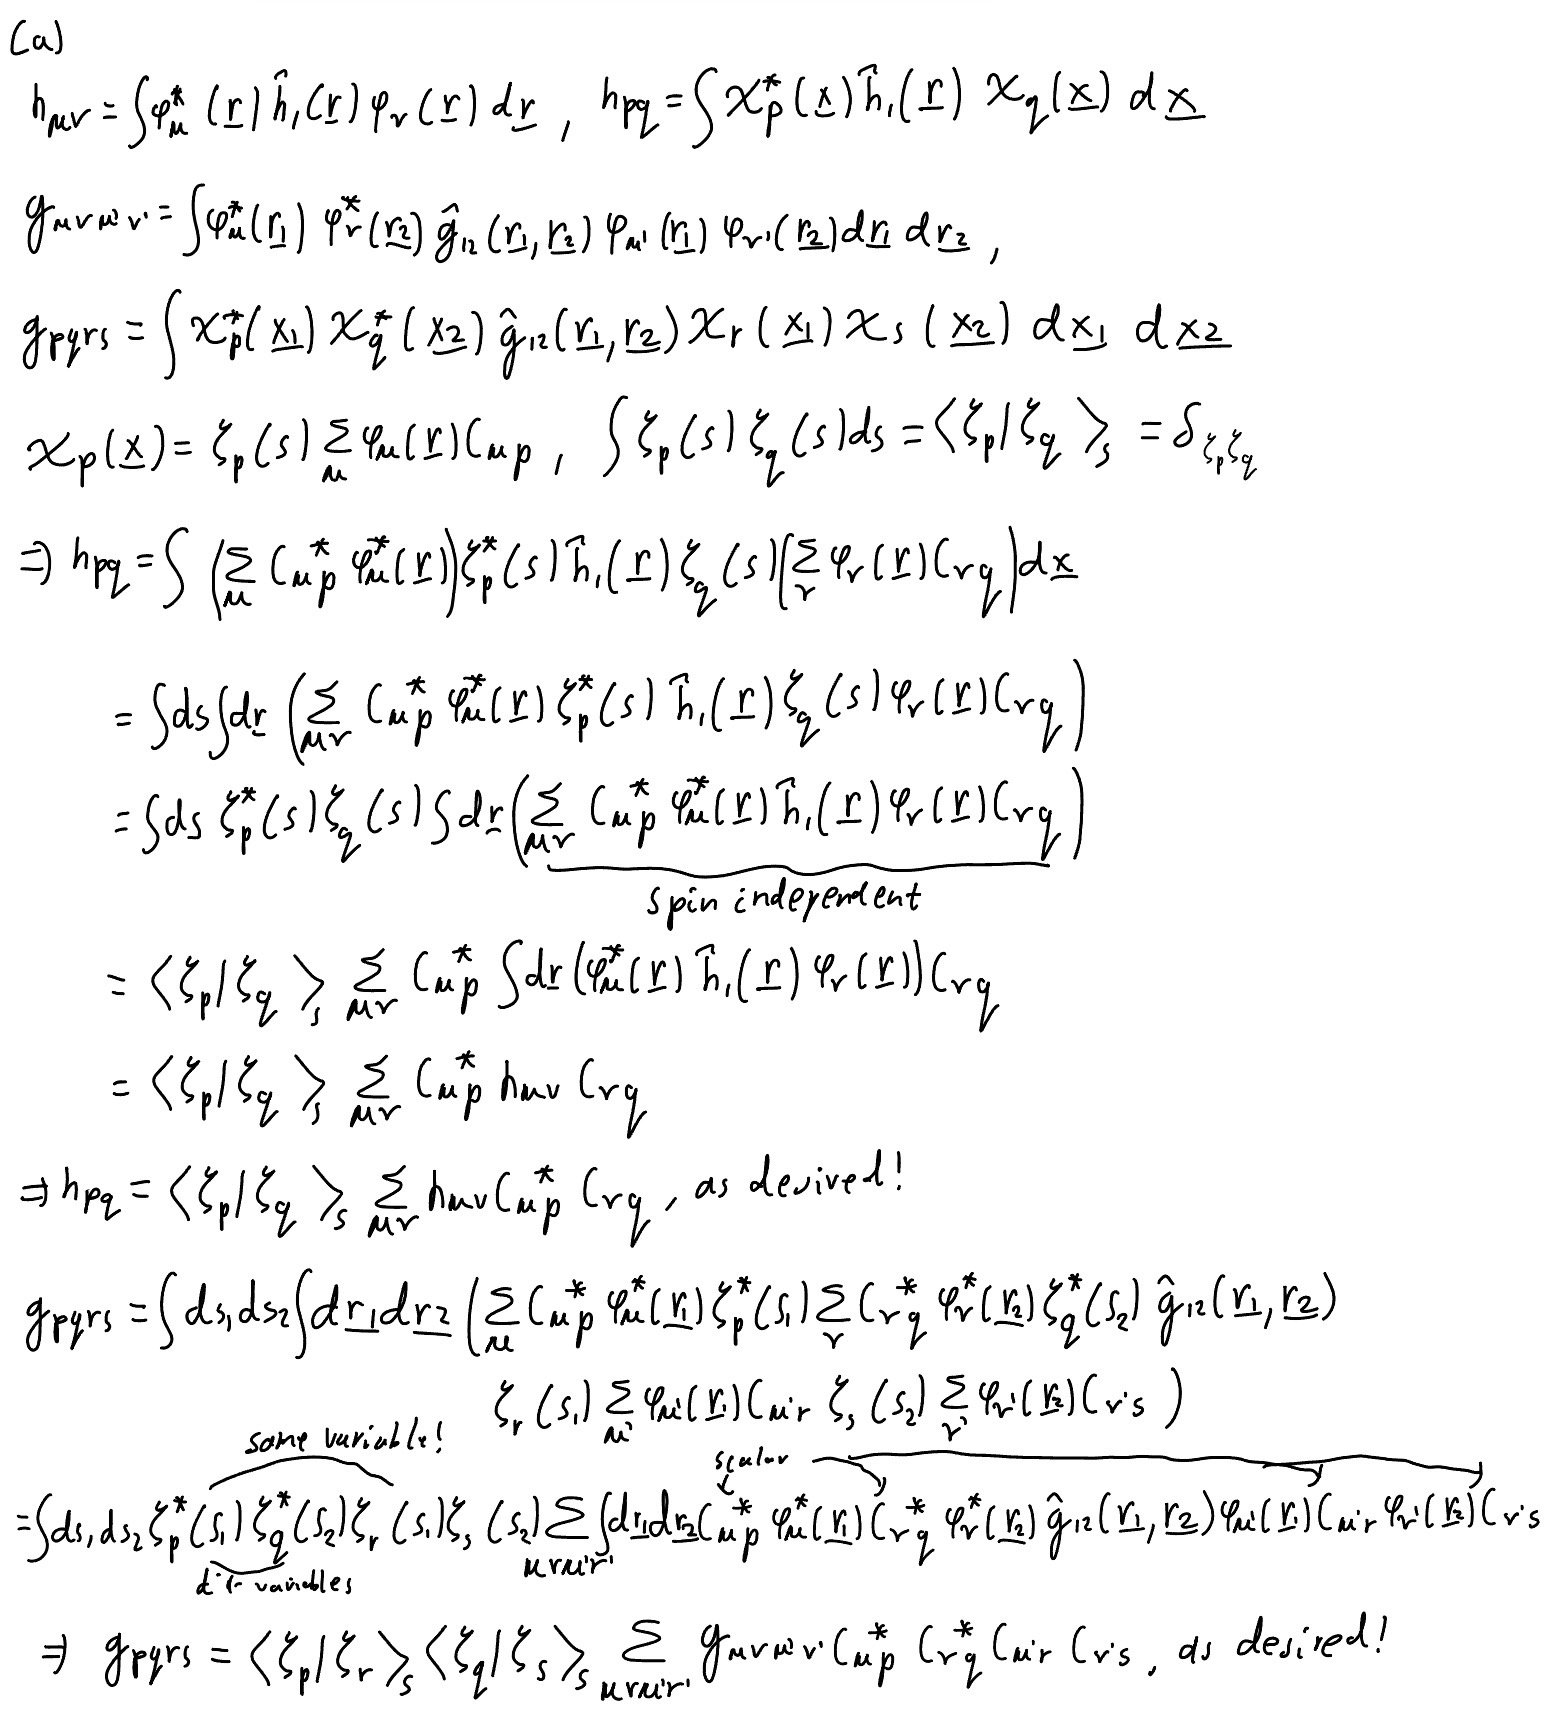

In [21]:
Image('2_2a.jpg')

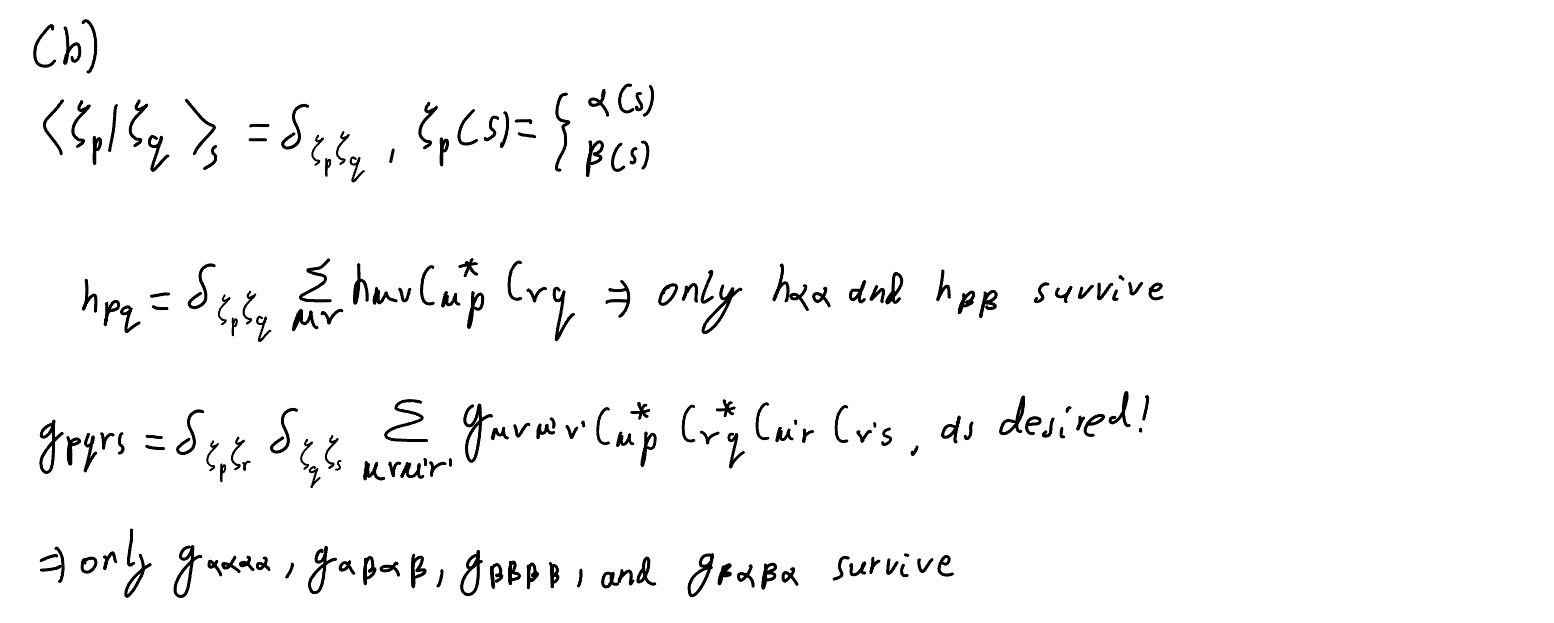

In [22]:
Image('2_2b.jpg')

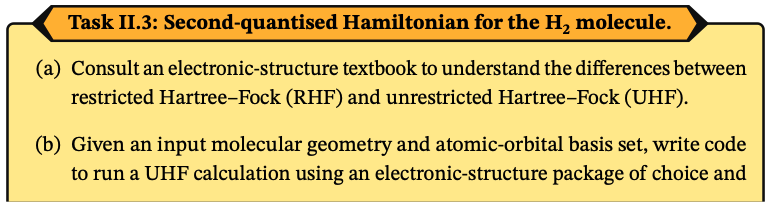

In [23]:
Image('2_3a.png')

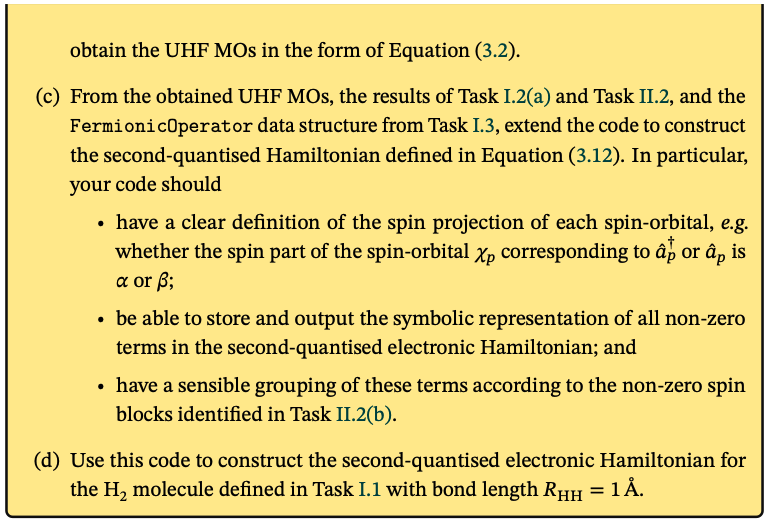

In [24]:
Image('2_3b.png')

**(a)**

Restricted Hartree-Fock (RHF) uses the same spatial orbital for the $\alpha$ and $\beta$ electrons in each pair. It works best for closed-shell molecules, however since the same spatial orbital is used, it cannot describe bond breaking into open-shell molecules/atoms. E.g. $H_2$ dissociates into $H^+$ and $H^-$, rather than two $H$ atoms.

Unrestricted Hartree-Fock (UHF) uses separate spatial orbitals for $\alpha$ and $\beta$ electrons. UHF can be used for open and closed shell molecules, and usually dissociates correctly. At equilibrium geometry for closed shell molecules, RHF and UHF wavefunctions are almost identical. RHF wavefunctions are usually used for closed shells, because it is cheaper, however it shouldn't be used for closed shells that may dissociate into open shells. Separate spatial orbitals introduce 'spin contamination' error, whose size depends on the chemical system involved [2].

**(b)**

In [25]:
def uhf_mos(atom, basis, unit="Angstrom", charge=0, spin=0):

    mol = gto.Mole()
    mol.atom = atom
    mol.unit = unit
    mol.basis = basis
    mol.charge = charge
    mol.spin = spin
    mol.build()

    
    mf = scf.UHF(mol)
    mf.verbose = 0 #no print
    mf.run()
    occ_alpha, occ_beta = mf.mo_occ
    E_uhf = mf.e_tot 
    
    C_alpha, C_beta = mf.mo_coeff
    ao_labels = mol.ao_labels()
    #all of these will be useful for later sections
    return C_alpha, C_beta, ao_labels, (occ_alpha, occ_beta), E_uhf

**(c)**

Note 1

Noting that $\sum_{\mu\nu}h_{\mu\nu}C_{\mu p}^*C_{\nu q}=\sum_{\mu}C_{\mu p}^*\sum_{\nu}h_{\mu\nu}C_{\nu q}=\sum_{\mu}\left(C^\dagger\right)_{p\mu}\left(hC\right)_{\mu q}=\left(C^\dagger hC\right)_{pq}$

Note 2

Noting the einstein summation used to find $g_{pqrs}$.

In [26]:
a = np.arange(16).reshape(2,2,2,2)
b = np.arange(4).reshape(2,2)
print(a)
print(b)

[[[[ 0  1]
   [ 2  3]]

  [[ 4  5]
   [ 6  7]]]


 [[[ 8  9]
   [10 11]]

  [[12 13]
   [14 15]]]]
[[0 1]
 [2 3]]


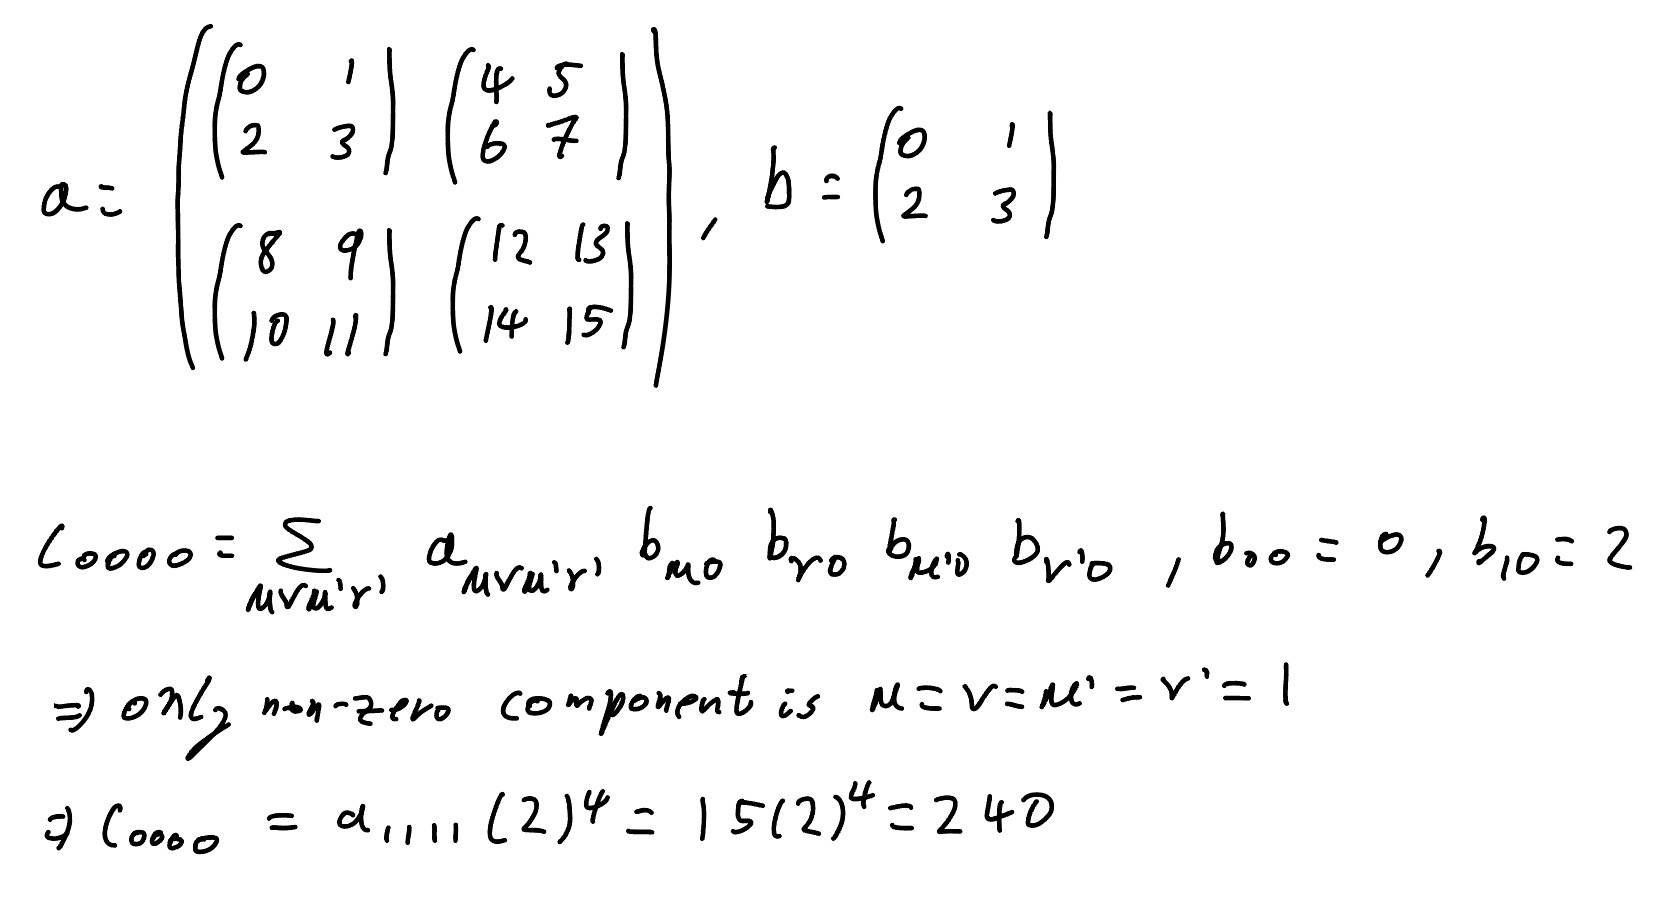

In [27]:
Image('note_2.jpg')

In [28]:
c=np.einsum('abcd,ap,bq,cr,ds->pqrs', a, b, b, b, b)
print(c)

[[[[ 240  472]
   [ 464  912]]

  [[ 448  880]
   [ 864 1696]]]


 [[[ 416  816]
   [ 800 1568]]

  [[ 768 1504]
   [1472 2880]]]]


$\Rightarrow g_{pqrs}=\sum_{\mu\nu\mu'\nu'}g_{\mu\nu\mu'\nu'}C^{*}_{\mu p} C^{*}_{\nu q} C_{\mu' r} C_{\nu' s}$ for the four cases identified in II.2(b).

In [29]:
def second_quantized_hamiltonian(atom, basis, unit = "Angstrom", charge = 0, spin = 0):    
    
    C_alpha, C_beta, ao_labels, (occ_alpha, occ_beta),E_uhf=uhf_mos(atom,basis,unit,charge, spin)
    h,g,v=core_and_eri(atom,basis,unit,charge,spin)

    # Note 1 above 
    h_aa = C_alpha.conj().T @ h @ C_alpha
    h_bb = C_beta.conj().T  @ h @ C_beta

    # Note 2 above
    g_aaaa = np.einsum('abcd,ap,bq,cr,ds->pqrs', g, C_alpha.conj(), C_alpha.conj(), C_alpha, C_alpha)
    g_bbbb = np.einsum('abcd,ap,bq,cr,ds->pqrs', g, C_beta.conj(),  C_beta.conj(),  C_beta,  C_beta)
    g_abab = np.einsum('abcd,ap,bq,cr,ds->pqrs', g, C_alpha.conj(), C_beta.conj(),  C_alpha, C_beta)
    g_baba = np.einsum('abcd,ap,bq,cr,ds->pqrs', g, C_beta.conj(),  C_alpha.conj(), C_beta,  C_alpha)
    
    h_αα=FermionicOperator()
    h_ββ=FermionicOperator()
    g_αααα=FermionicOperator()
    g_αβαβ=FermionicOperator()
    g_βαβα=FermionicOperator()
    g_ββββ=FermionicOperator()
    
    nmo = h_aa.shape[0]  # number of spatial molecular orbitals (same for both?)

    for p in range(nmo):
        for q in range(nmo):
            #one-electron terms
            h_αα += FermionicOperator.string([(2*p, 1), (2*q, 0)], h_aa[p, q])
            # need different indexing since a_α neq a_β, have α even, β odd
            h_ββ += FermionicOperator.string([(2*p+1, 1), (2*q+1, 0)], h_bb[p, q])
            for r in range(nmo):
                for s in range(nmo):
                    #two-electron terms
                    #swap q and r as using chemist notation
                    g_αααα+=FermionicOperator.string([(2*p, 1), (2*q, 1), (2*s, 0), (2*r, 0)],g_aaaa[p,r,q,s])
                    g_αβαβ+=FermionicOperator.string([(2*p, 1), (2*q+1, 1), (2*s+1, 0), (2*r, 0)],g_abab[p,r,q,s])
                    g_βαβα+=FermionicOperator.string([(2*p+1, 1), (2*q, 1), (2*s, 0), (2*r+1, 0)],g_baba[p,r,q,s])
                    g_ββββ+=FermionicOperator.string([(2*p+1, 1), (2*q+1, 1), (2*s+1, 0), (2*r+1, 0)],g_bbbb[p,r,q,s])       
                        
    H = h_αα + h_ββ + 0.5*(g_αααα + g_αβαβ + g_βαβα + g_ββββ) + FermionicOperator.string([], v)#need constant of same form
    return H

**(d)**

In [30]:
atom = """
H 0 0 0
H 0 0 1
"""
basis = "sto-3g"

H = second_quantized_hamiltonian(atom=atom, basis="sto-3g")
print(H)

(0.52917721092+0j) [] +
(-1.110844179883727+0j) [0^ 0] +
(0.3132012497647588+0j) [0^ 0^ 0 0] +
(0.09839529174273509+0j) [0^ 0^ 2 2] +
(0.3132012497647588+0j) [0^ 1^ 1 0] +
(0.09839529174273509+0j) [0^ 1^ 3 2] +
(0.09839529174273508+0j) [0^ 2^ 0 2] +
(0.3108533815598566+0j) [0^ 2^ 2 0] +
(0.09839529174273508+0j) [0^ 3^ 1 2] +
(0.3108533815598566+0j) [0^ 3^ 3 0] +
(0.3132012497647588+0j) [1^ 0^ 0 1] +
(0.09839529174273509+0j) [1^ 0^ 2 3] +
(-1.110844179883727+0j) [1^ 1] +
(0.3132012497647588+0j) [1^ 1^ 1 1] +
(0.09839529174273509+0j) [1^ 1^ 3 3] +
(0.09839529174273508+0j) [1^ 2^ 0 3] +
(0.3108533815598566+0j) [1^ 2^ 2 1] +
(0.09839529174273508+0j) [1^ 3^ 1 3] +
(0.3108533815598566+0j) [1^ 3^ 3 1] +
(0.31085338155985676+0j) [2^ 0^ 0 2] +
(0.09839529174273512+0j) [2^ 0^ 2 0] +
(0.31085338155985676+0j) [2^ 1^ 1 2] +
(0.09839529174273512+0j) [2^ 1^ 3 0] +
(-0.5891210037060842+0j) [2^ 2] +
(0.0983952917427351+0j) [2^ 2^ 0 0] +
(0.3265353734712868+0j) [2^ 2^ 2 2] +
(0.0983952917427351+0j) [2^ 

Compare against PySCF [5].

In [31]:
mol = MolecularData(atom, basis, multiplicity=1)
mol = run_pyscf(mol)

H_ref = get_fermion_operator(mol.get_molecular_hamiltonian()) 
print(H_ref)

0.52917721092 [] +
-1.110844179883727 [0^ 0] +
0.3132012497647589 [0^ 0^ 0 0] +
0.09839529174273509 [0^ 0^ 2 2] +
0.3132012497647589 [0^ 1^ 1 0] +
0.09839529174273509 [0^ 1^ 3 2] +
0.09839529174273509 [0^ 2^ 0 2] +
0.3108533815598565 [0^ 2^ 2 0] +
0.09839529174273509 [0^ 3^ 1 2] +
0.3108533815598565 [0^ 3^ 3 0] +
0.3132012497647589 [1^ 0^ 0 1] +
0.09839529174273509 [1^ 0^ 2 3] +
-1.110844179883727 [1^ 1] +
0.3132012497647589 [1^ 1^ 1 1] +
0.09839529174273509 [1^ 1^ 3 3] +
0.09839529174273509 [1^ 2^ 0 3] +
0.3108533815598565 [1^ 2^ 2 1] +
0.09839529174273509 [1^ 3^ 1 3] +
0.3108533815598565 [1^ 3^ 3 1] +
0.31085338155985676 [2^ 0^ 0 2] +
0.09839529174273509 [2^ 0^ 2 0] +
0.31085338155985676 [2^ 1^ 1 2] +
0.09839529174273509 [2^ 1^ 3 0] +
-0.5891210037060843 [2^ 2] +
0.09839529174273509 [2^ 2^ 0 0] +
0.3265353734712868 [2^ 2^ 2 2] +
0.09839529174273509 [2^ 3^ 1 0] +
0.3265353734712868 [2^ 3^ 3 2] +
0.31085338155985676 [3^ 0^ 0 3] +
0.09839529174273509 [3^ 0^ 2 1] +
0.31085338155985676 [3

Good agreement.

#### Transitioning from electrons to qubits

To implement second-quantised electronic states and Hamiltonians on a quantum computer, they are mapped to operators acting on qubits, expressed as linear combinations of tensor products of single-qubit Pauli operators.

On qubit $p$, the elementary Pauli operators $\hat I_p,\hat X_p,\hat Y_p,\hat Z_p$ act on the computational basis $\{|0_p\rangle,|1_p\rangle\}$ and are represented by
$$
\mathbf{I}=\begin{pmatrix}1&0\\0&1\end{pmatrix},\quad
\mathbf{X}=\begin{pmatrix}0&1\\1&0\end{pmatrix},\quad
\mathbf{Y}=\begin{pmatrix}0&-i\\ i&0\end{pmatrix},\quad
\mathbf{Z}=\begin{pmatrix}1&0\\0&-1\end{pmatrix}.
$$

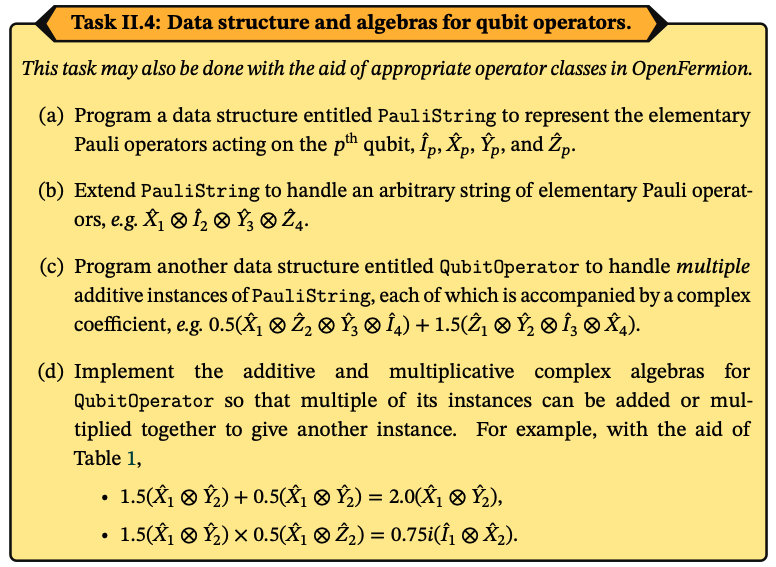

In [32]:
Image('2_4.png')

First verify multiplication rules, leaving out identity since it is trivial. Do they agree with the table given in the laboratory manual [1]?

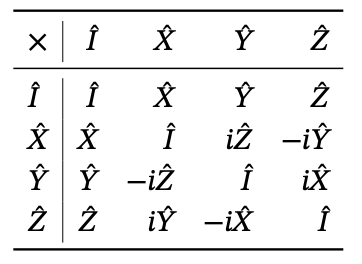

In [33]:
Image('mult_table.png')

In [34]:
X = np.array([[0, 1], [1, 0]], dtype=complex)
Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)

print("XX =",X@X)
print("\nXY =",X@Y)
print("\nXZ =",X@Z)
print("\nYX =",Y@X)
print("\nYY =",Y@Y)
print("\nYZ =",Y@Z)
print("\nZX =",Z@X)
print("\nZY =",Z@Y)
print("\nZZ =",Z@Z)

XX = [[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]

XY = [[0.+1.j 0.+0.j]
 [0.+0.j 0.-1.j]]

XZ = [[ 0.+0.j -1.+0.j]
 [ 1.+0.j  0.+0.j]]

YX = [[0.-1.j 0.+0.j]
 [0.+0.j 0.+1.j]]

YY = [[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]

YZ = [[0.+0.j 0.+1.j]
 [0.+1.j 0.+0.j]]

ZX = [[ 0.+0.j  1.+0.j]
 [-1.+0.j  0.+0.j]]

ZY = [[0.+0.j 0.-1.j]
 [0.-1.j 0.+0.j]]

ZZ = [[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]


As desired.

**(a)**

In [35]:
class PauliString:
    def __init__(self, ops=()):  #ops like [(1,"X"), (2,"I"),...]
        self._qop = ofQubitOperator(())  #identity
#(b)
        for p, op in ops:
            if op != "I":
                self._qop *= ofQubitOperator(((p, op),), 1.0)

    def __str__(self): 
        return str(self._qop)
        
    def to_openfermion(self): 
        return self._qop

Note that an error message is printed if a string other than $I,X,Y$, or $Z$ is entered.

In [36]:
print(PauliString([(1,"X"),(2,"I"),(3,"Y"),(4,"Z")]))

1.0 [X1 Y3 Z4]


**(c)**

In [37]:
class QubitOperator:
    def __init__(self, terms=()):
        self._qop = ofQubitOperator()#zero operator
        for coeff, ps in terms:
            self._qop += coeff * ps.to_openfermion()

    def to_openfermion(self):
        return self._qop

    def __str__(self):
        return str(self._qop)
#(d)
    def __add__(self, other):
        out = QubitOperator()
        out._qop = self._qop + other._qop
        return out

    def __mul__(self, other):
        out = QubitOperator()
        out._qop = self._qop * other._qop
        return out

    def __rmul__(self, other):
        out = QubitOperator()
        out._qop = other * self._qop    
        return out

In [38]:
psA = PauliString([(1,"X"), (2,"Y")])
psB = PauliString([(1,"X"), (2,"Z")])
a=QubitOperator([(1.5,psA),(0.5,psA)])
b=QubitOperator([(1.5,psA)])
c=QubitOperator([(0.5,psB)])
print(a)
print(b*c)

2.0 [X1 Y2]
0.75j [X2]


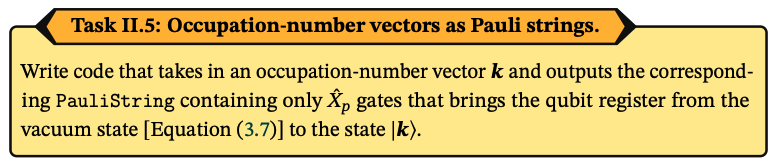

In [39]:
Image('2_5.png')

In [40]:
def occupation_to_paulistring(k):
    ops = [(p, "X") for p, occ in enumerate(k) if occ]
    return PauliString(ops)

ps = occupation_to_paulistring(k1)
print(ps)

1.0 [X0 X2]


#### Jordan-Wigner transformation

In the occupation basis, each spin-orbital $p$ is mapped to a qubit with $|1\rangle$ denoting occupied and $|0\rangle$ denoting vacant. 

To represent fermionic creation and annihilation operators by qubit operators that act identically on occupation-number states, define the Jordan-Wigner qubit operators
$$
\hat q_p^\dagger=\left(\bigotimes_{q=0}^{p-1}\hat Z_q\right)\,\frac{\hat X_p-i\hat Y_p}{2},
\qquad
\hat q_p=\left(\bigotimes_{q=0}^{p-1}\hat Z_q\right)\,\frac{\hat X_p+i\hat Y_p}{2}.
$$
Then the mapping is
$$
|\mathbf k\rangle \ \leftrightarrow\  |k_0k_1\cdots k_{M-1}\rangle,\qquad
\hat a_p^\dagger \ \leftrightarrow\ \hat q_p^\dagger,\qquad
\hat a_p \ \leftrightarrow\ \hat q_p,
$$
so fermionic operators (and hence $\hat H$) can be converted into sums of Pauli strings acting on qubits [1].

Verifying that $\hat{a}^\dagger_p \leftrightarrow \hat{q}^\dagger_p$ and $\hat{a}_p \leftrightarrow \hat{q}_p$. Noting that for this example the first $q$ has index $1$, like in the manual.

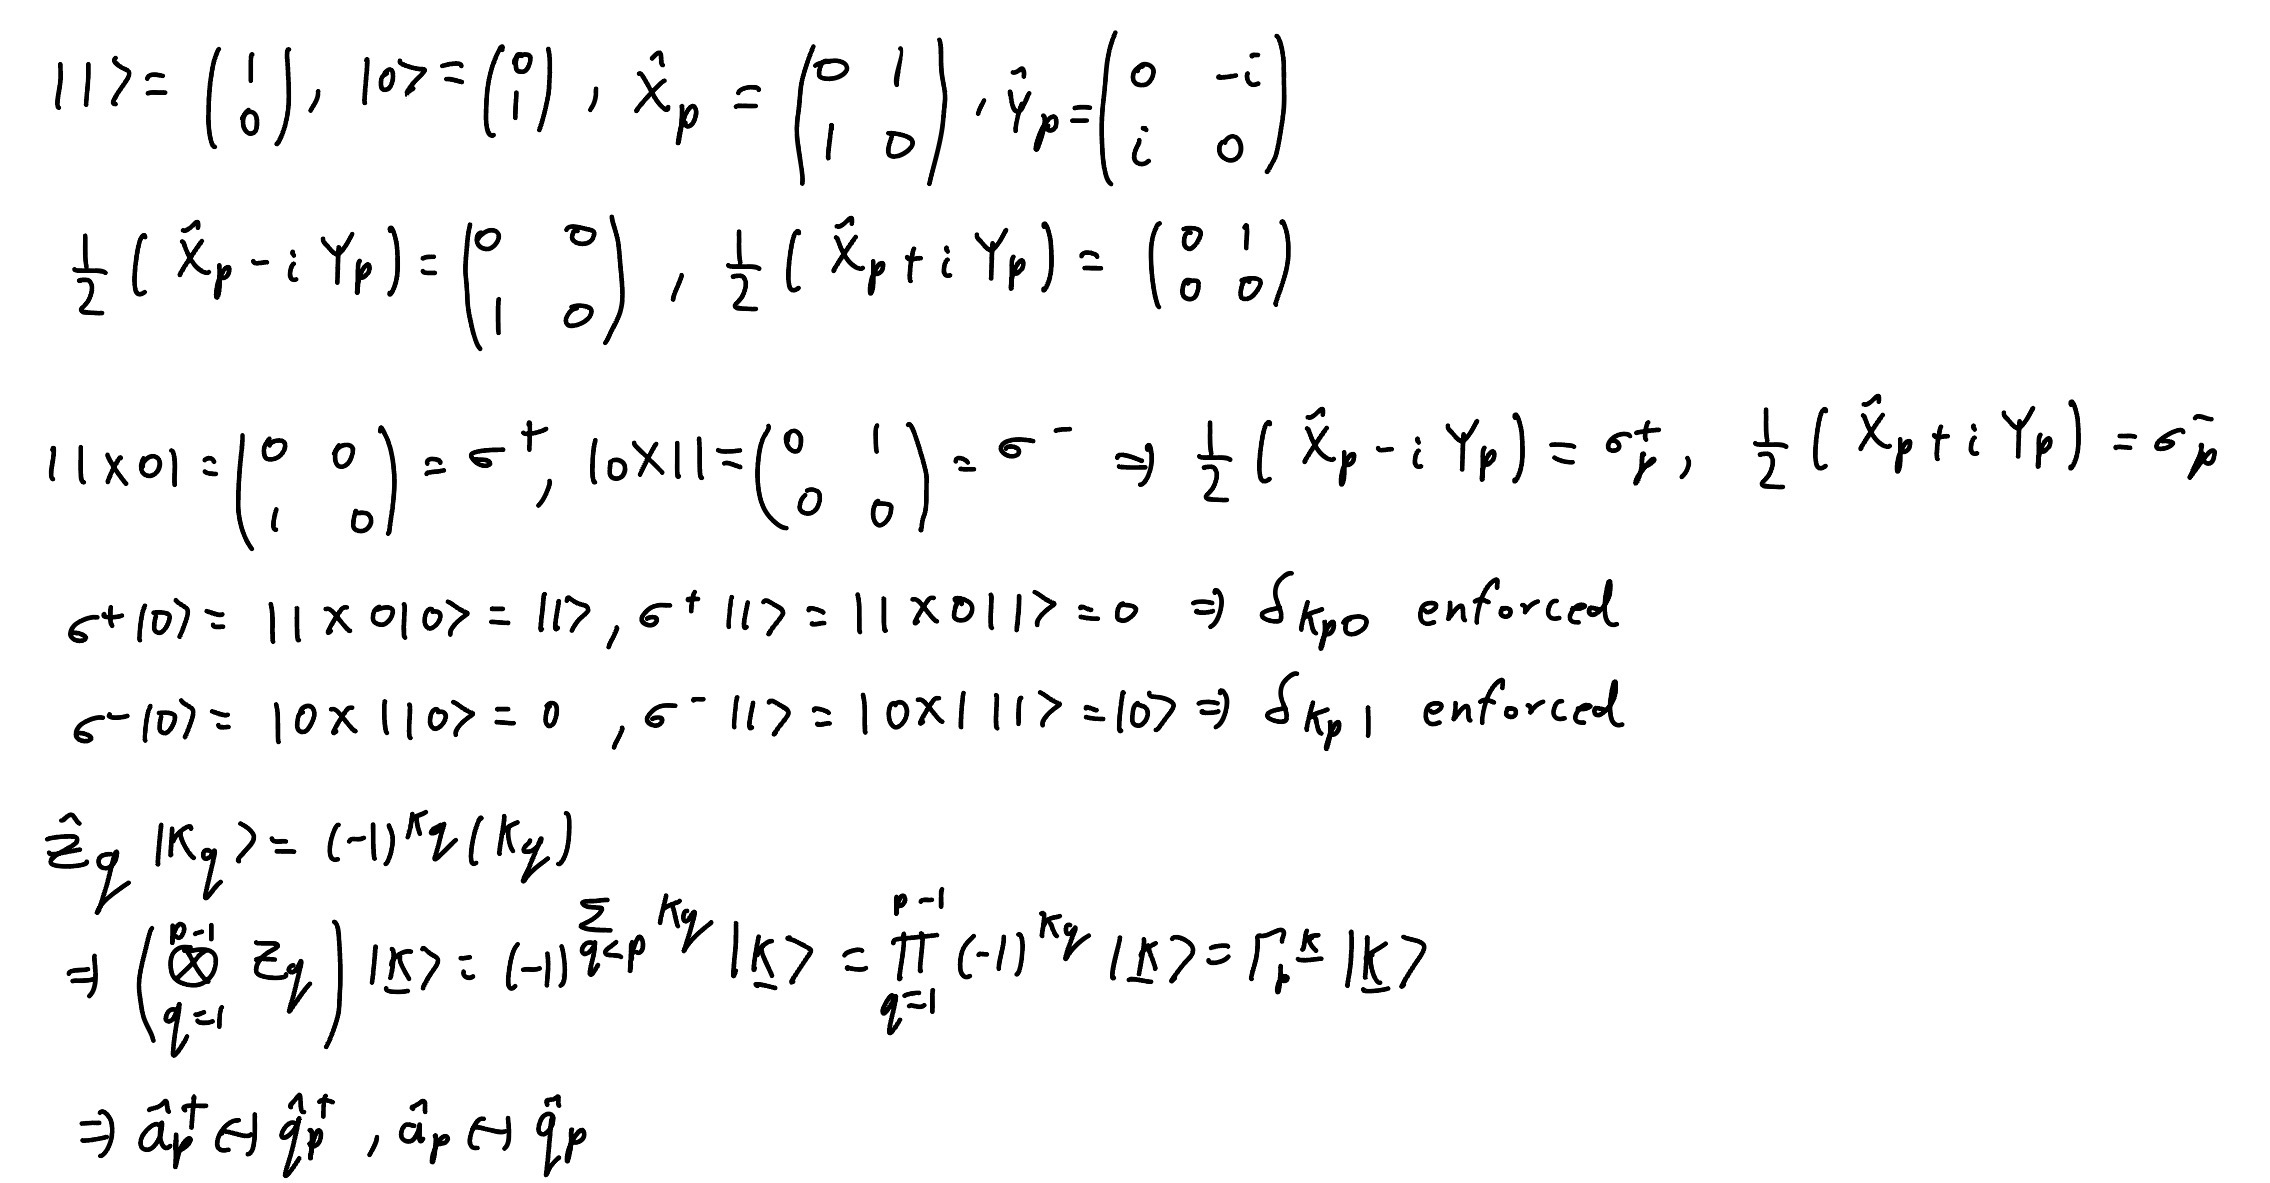

In [41]:
Image('JW.jpg')

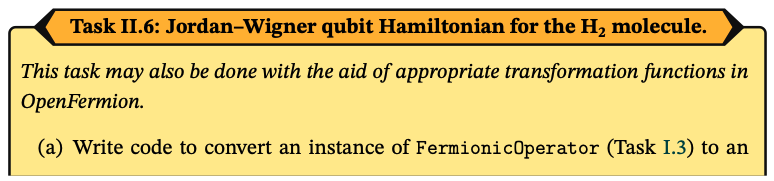

In [42]:
Image('2_6a.png')

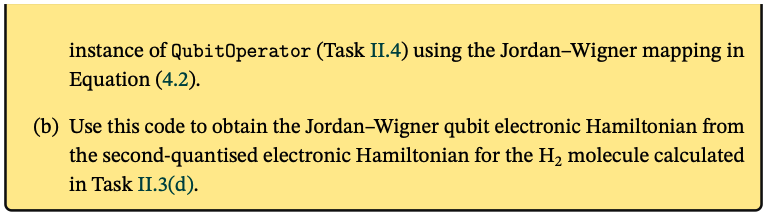

In [43]:
Image('2_6b.png')

**(a)**

In [44]:
# rough work for of_ferm.terms.items()
a=FermionicOperator.string([(1,1), (2,1), (3,0), (4,0)], 0.5).to_openfermion()
a.terms.items()

dict_items([(((1, 1), (2, 1), (3, 0), (4, 0)), (0.5+0j))])

In [45]:
def jw_transform(ferm_op):
    of_ferm = ferm_op.to_openfermion()
    qop = ofQubitOperator() 

    for term, coeff in of_ferm.terms.items():
        jw = ofQubitOperator((), 1.0) 

        for p, ca in term:
            # Z string
            for q in range(p):
                jw *= ofQubitOperator(((q,"Z"),), 1.0)
            if ca == 1:   
                #creation
                jw *= (0.5 * ofQubitOperator(((p,"X"),), 1.0) - 0.5j * ofQubitOperator(((p,"Y"),), 1.0))
            else:             
                # annihilation
                jw *= (0.5 * ofQubitOperator(((p,"X"),), 1.0) + 0.5j * ofQubitOperator(((p,"Y"),), 1.0))

        qop += complex(coeff) * jw

    mapped = QubitOperator()
    mapped._qop = qop
    #map to QubitOperator class
    return mapped

**(b)**

In [46]:
H_q = jw_transform(H)
print(H_q)

(-0.32760818967481076+0j) [] +
(-0.049197645871367546+0j) [X0 X1 Y2 Y3] +
(0.049197645871367546+0j) [X0 Y1 Y2 X3] +
(0.049197645871367546+0j) [Y0 X1 X2 Y3] +
(-0.049197645871367546+0j) [Y0 Y1 X2 X3] +
(0.13716572937099492+0j) [Z0] +
(0.1566006248823794+0j) [Z0 Z1] +
(0.10622904490856078+0j) [Z0 Z2] +
(0.15542669077992832+0j) [Z0 Z3] +
(0.13716572937099483+0j) [Z1] +
(0.15542669077992832+0j) [Z1 Z2] +
(0.10622904490856078+0j) [Z1 Z3] +
(-0.13036292057109045+0j) [Z2] +
(0.1632676867356434+0j) [Z2 Z3] +
(-0.13036292057109042+0j) [Z3]


Note that Pauli operators acting on different qubits commute (i.e. $\hat{X}_0 \hat{X}_1 \hat{Y}_2 \hat{Y}_3=\hat{Y}_2\hat{X}_1\hat{X}_0\hat{Y}_3$), so order doesn't matter. Pauli operators acting on the same qubit generally do not commute (i.e. $\hat{X}_p \hat{Y}_p = i \hat{Z}_p$ while $\hat{Y}_p \hat{X}_p = -i \hat{Z}_p$), so ordering matters when multiple Paulis act on the same qubit.

Compare against PySCF.

In [47]:
atom = """
H 0 0 0
H 0 0 1
"""
mol = MolecularData(atom, "sto-3g", multiplicity=1)
mol = run_pyscf(mol)

H_ref = jordan_wigner(mol.get_molecular_hamiltonian()) 
print(H_ref)

-0.3276081896748101 [] +
-0.049197645871367546 [X0 X1 Y2 Y3] +
0.049197645871367546 [X0 Y1 Y2 X3] +
0.049197645871367546 [Y0 X1 X2 Y3] +
-0.049197645871367546 [Y0 Y1 X2 X3] +
0.13716572937099492 [Z0] +
0.15660062488237944 [Z0 Z1] +
0.10622904490856078 [Z0 Z2] +
0.15542669077992832 [Z0 Z3] +
0.13716572937099492 [Z1] +
0.15542669077992832 [Z1 Z2] +
0.10622904490856078 [Z1 Z3] +
-0.13036292057109033 [Z2] +
0.1632676867356434 [Z2 Z3] +
-0.13036292057109033 [Z3]


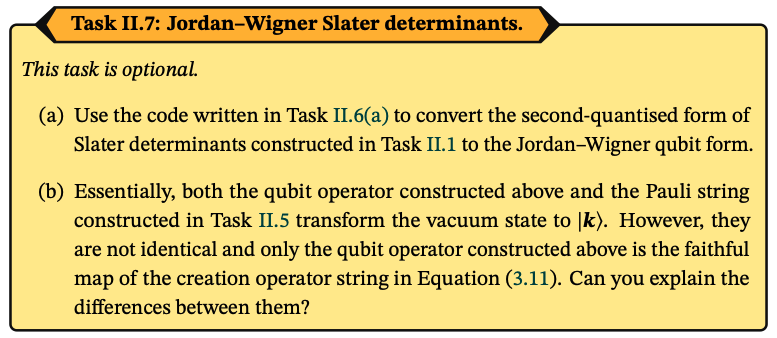

In [48]:
Image('2_7.png')

**(a)**

In [49]:
op = occupation_to_operator(k1)
print('For second-quantized k1 =',op.to_openfermion(),'the Jordan-Wigner qubit form is:',jw_transform(op))  

For second-quantized k1 = (1+0j) [0^ 2^] the Jordan-Wigner qubit form is: (0.25+0j) [X0 Z1 X2] +
-0.25j [X0 Z1 Y2] +
-0.25j [Y0 Z1 X2] +
(-0.25+0j) [Y0 Z1 Y2]


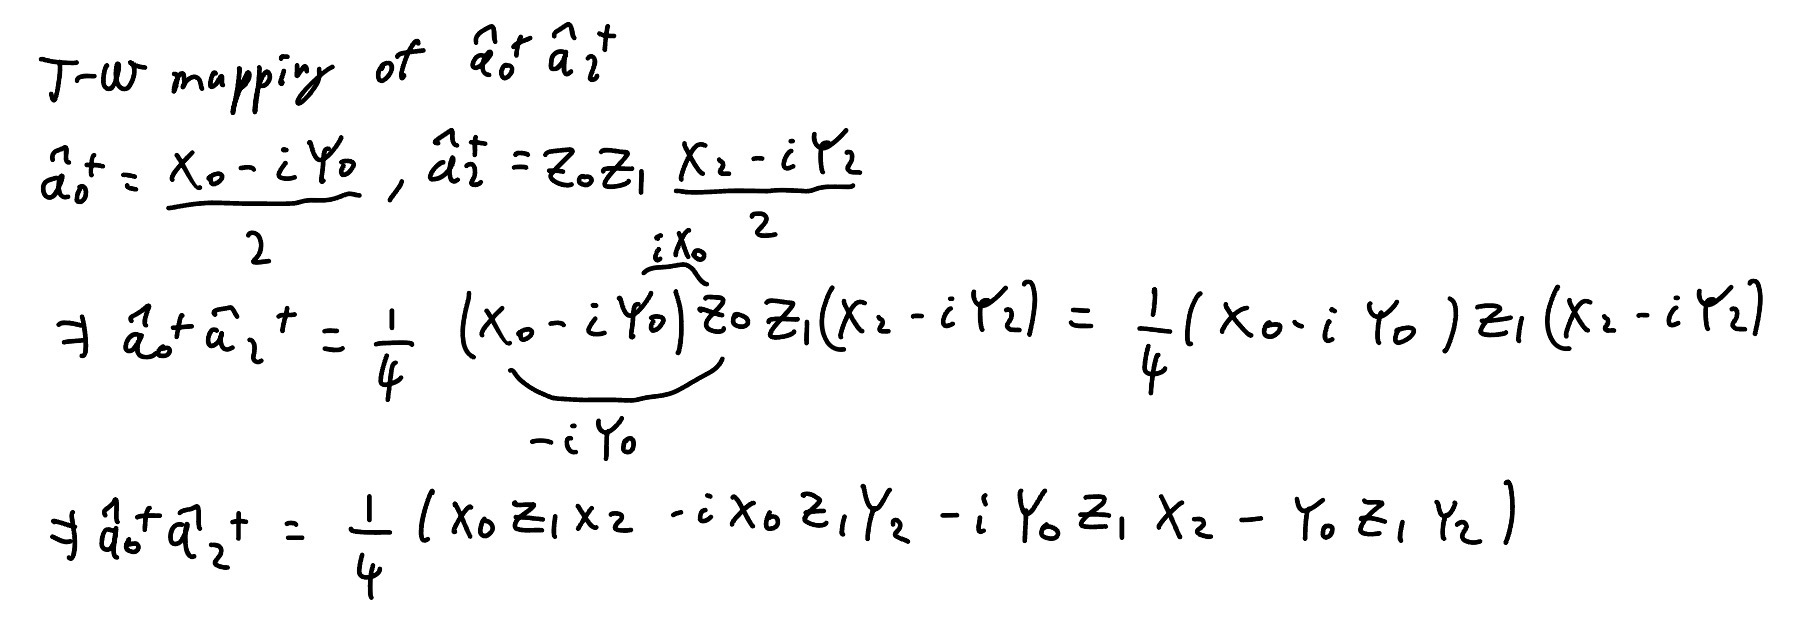

In [50]:
Image('JWexample.jpg')

**(b)**

Jordan-Wigner mapping is the true operator map of $\prod_p (a_p^\dagger)^{k_p}$, including the parity string $\bigotimes_{q=0}^{p-1} \hat{Z}_q$ and the $(\hat{X}_p \mp i\hat{Y}_p)/2$ structure, so it expands into a sum of Pauli strings that preserves fermionic anticommutation.

The Pauli string $\hat{X}_0\hat{X}_2$ is only a state preparation shortcut that flips $|000\rangle \to |101\rangle$. It does not enforce fermionic occupancy rules or anticommutation. For example $\hat{X}_0\hat{X}_2|011\rangle = |110\rangle$, while $\hat a_0^\dagger \hat a_2^\dagger|011\rangle = 0$ because creating on an already occupied mode gives zero.

## Module 2 Logbook 

This laboratory extended the second quantisation formalism to the electronic Hamiltonian and introduced the Jordan-Wigner transformation, which maps fermionic creation and annihilation operators to Pauli operators on qubits. A comparison between simply applying $X$ operators and the full Jordan-Wigner mapping showed that while the simple method can reproduce the correct bitstring for some state preparations, it does not implement fermionic creation and annihilation operators.

The Jordan-Wigner mapping was implemented with the parity $Z$ string and the $(X\mp iY)/2$ structure, applied term by term to each fermionic string. Even though each elementary fermionic operator maps to only two Pauli terms, multiplying several of them together produces large strings.

The main computational consideration for PauliString and QubitOperator was to keep them as simple and general as possible. OpenFermion’s QubitOperator was used for the bookkeeping, combining like terms and keeping a consistent ordering. A thin wrapper was then added to provide addition and multiplication.

Correctness was checked using the same workflow the code is meant for. The elementary Pauli multiplication rules were verified directly by matrix multiplication of $X$, $Y$, and $Z$. Then, the PauliString and QubitOperator classes were tested on the specific addition and multiplication examples provided, confirming that identical Pauli strings combined correctly by coefficient addition and that multiplication produced the expected phase factors and Pauli products. The second quantised $H_2$ Hamiltonian constructed from the UHF Molecular Orbital transformation was compared against an OpenFermion reference Hamiltonian generated from PySCF output, and the term list agreed (up to numerical precision). Finally, the Jordan-Wigner Hamiltonian produced by the custom mapping was compared against OpenFermion's built in transform, and the resulting Pauli terms and coefficients matched.

# Part III
## Simulation Framework

#### Classical simulation of state-vectors

An $M$-qubit pure state in the computational basis can be stored classically as a length $2^M$ state-vector of complex amplitudes. For a product state
$$
|\Psi_q\rangle=\bigotimes_{p=0}^{M-1}|\psi_p\rangle,\qquad |\psi_p\rangle=c_{p,0}|0_p\rangle+c_{p,1}|1_p\rangle,\quad |c_{p,0}|^2+|c_{p,1}|^2=1,
$$
the corresponding state-vector entries are amplitudes for basis states $|i_0i_1\cdots i_{M-1}\rangle$:
$$
V_{i_0i_1\cdots i_{M-1}}=\prod_{p=0}^{M-1} c_{p,i_p},\qquad i_p\in\{0,1\},
$$
and $|V_{i_0i_1\cdots i_{M-1}}|^2$ gives the associated frequency [1].

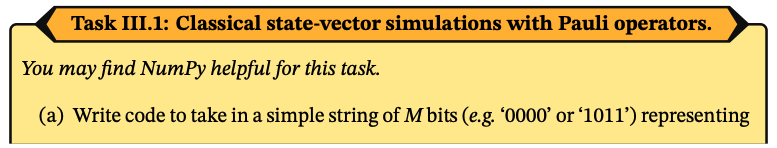

In [51]:
Image('3_1a.png')

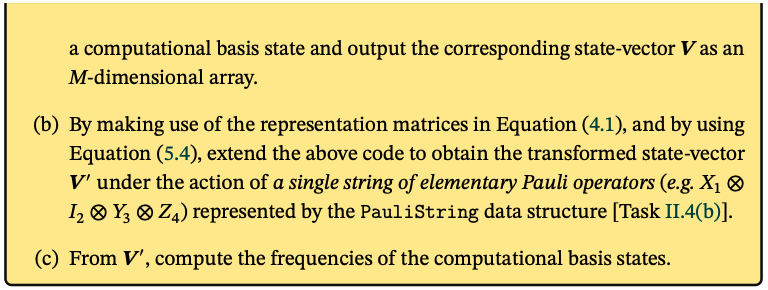

In [52]:
Image('3_1b.png')

**(a)**

In [53]:
def b_svtensor(bstr):
    bits = tuple(int(b) for b in bstr.strip())
    M = len(bits)
    V = np.zeros((2,) * M, dtype=complex)
    V[bits] = 1 #sets amplitude of bstr to 1
    return V

In [54]:
V = b_svtensor("1011")
print("Shape of V:",V.shape)
print("V[1,0,1,1]:",V[1,0,1,1]) 
print("V:",V)

Shape of V: (2, 2, 2, 2)
V[1,0,1,1]: (1+0j)
V: [[[[0.+0.j 0.+0.j]
   [0.+0.j 0.+0.j]]

  [[0.+0.j 0.+0.j]
   [0.+0.j 0.+0.j]]]


 [[[0.+0.j 0.+0.j]
   [0.+0.j 1.+0.j]]

  [[0.+0.j 0.+0.j]
   [0.+0.j 0.+0.j]]]]


**(b)**

Note 3

If a $k$-qubit unitary $\hat U$ acts on selected qubits, the updated state-vector $V'$ is obtained by contracting $\hat U$ with $V$ over the acted-upon indices. 
$\Rightarrow V'_{\cdots i_{p-1}'ai_{p+1}' \cdots}=\sum_{b}V_{\cdots i_{p-1}bi_{p+1}\cdots}U_{ab}.$

Since the state-vector dimension scales as $2^M$, only small $M$ classical simulations are possible [1].

In [55]:
pauli = {"I": np.eye(2, dtype=complex),"X": np.array([[0, 1], [1, 0]], dtype=complex),
         "Y": np.array([[0, -1j], [1j, 0]], dtype=complex),"Z": np.array([[1, 0], [0, -1]], dtype=complex)}

def apply_paulistring(V, ps):
    #V from b_svtensor
    qop = ps.to_openfermion()
    terms = list(qop.terms.items())
        
    term, coeff = terms[0]   
    # term is e.g. ((p,'X'), (q,'Z'), ...)
    Vp = V * coeff
    for p, op in term:
        Vp = np.tensordot(pauli[op], Vp, axes=([1], [p])) #note 3
        Vp = np.moveaxis(Vp, 0, p) #tensordot inserts the new output index of the Pauli matrix as axis 0
    return Vp

**(c)**

In [56]:
def frequencies(Vp):
    probs = np.abs(Vp)**2
    return probs                

In [57]:
V = b_svtensor("1011")  
ps = PauliString([(0,"X"), (1,"I"), (2,"Y"), (3,"Z")])
#arbitrary

Vp = apply_paulistring(V, ps)
freq = frequencies(Vp)
print("V':",Vp)
print("\nFrequency:",freq)
print("\nSum of frequencies:",freq.sum())
print("V'[0,0,0,1]:",Vp[0,0,0,1]) 

V': [[[[0.+0.j 0.+1.j]
   [0.+0.j 0.+0.j]]

  [[0.+0.j 0.+0.j]
   [0.+0.j 0.+0.j]]]


 [[[0.+0.j 0.+0.j]
   [0.+0.j 0.+0.j]]

  [[0.+0.j 0.+0.j]
   [0.+0.j 0.+0.j]]]]

Frequency: [[[[0. 1.]
   [0. 0.]]

  [[0. 0.]
   [0. 0.]]]


 [[[0. 0.]
   [0. 0.]]

  [[0. 0.]
   [0. 0.]]]]

Sum of frequencies: 1.0
V'[0,0,0,1]: 1j


Try $X_0Z_0\otimes I_1\otimes Y_2\otimes Z_3 \otimes Z_4$.

In [58]:
V = b_svtensor("10110") 

ps = PauliString([(4,"Z")])
Vp = apply_paulistring(V, ps)

ps1 = PauliString([(4,"X"), (3,"I"), (2,"Y"), (1,"Z"),(0,"Z")])
Vp = apply_paulistring(Vp, ps1)
freq = frequencies(Vp)

print("V':",Vp)
print("\nFrequency:",freq)
print("\nSum of frequencies:",freq.sum())
print("V'[1,0,0,1,1]:",Vp[1,0,0,1,1]) 

V': [[[[[0.+0.j 0.+0.j]
    [0.+0.j 0.+0.j]]

   [[0.+0.j 0.+0.j]
    [0.+0.j 0.+0.j]]]


  [[[0.+0.j 0.+0.j]
    [0.+0.j 0.+0.j]]

   [[0.+0.j 0.+0.j]
    [0.+0.j 0.+0.j]]]]



 [[[[0.+0.j 0.+0.j]
    [0.+0.j 0.+1.j]]

   [[0.+0.j 0.+0.j]
    [0.+0.j 0.+0.j]]]


  [[[0.+0.j 0.+0.j]
    [0.+0.j 0.+0.j]]

   [[0.+0.j 0.+0.j]
    [0.+0.j 0.+0.j]]]]]

Frequency: [[[[[0. 0.]
    [0. 0.]]

   [[0. 0.]
    [0. 0.]]]


  [[[0. 0.]
    [0. 0.]]

   [[0. 0.]
    [0. 0.]]]]



 [[[[0. 0.]
    [0. 1.]]

   [[0. 0.]
    [0. 0.]]]


  [[[0. 0.]
    [0. 0.]]

   [[0. 0.]
    [0. 0.]]]]]

Sum of frequencies: 1.0
V'[1,0,0,1,1]: 1j


Now compare against Qiskit's classical state-vector simulators. Note that Qiskit uses the rightmost bit as qubit $0$ convention, which will be used for the remaining sections.

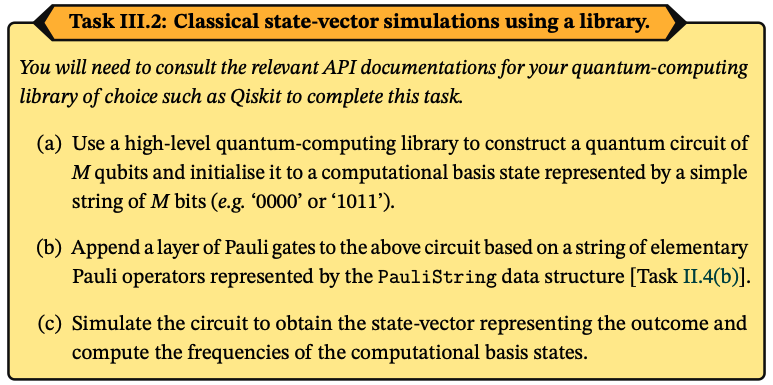

In [59]:
Image('3_2.png')

In [60]:
service = QiskitRuntimeService(name="oxford-chem")

management.get:WARNING:2026-03-05 11:05:40,927: Loading saved account: oxford-chem


**(a)**

'0000'


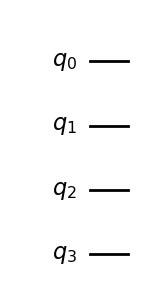

In [61]:
qc0000 = QuantumCircuit(4)


print("'0000'")
qc0000.draw("mpl")


'1011'


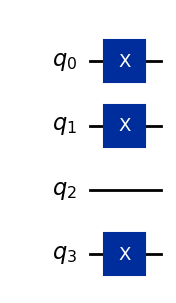

In [62]:
qc1011 = QuantumCircuit(4)
qc1011.x(0)
qc1011.x(1)
qc1011.x(3)
print("'1011'")
qc1011.draw("mpl")

**(b)**

In [63]:
def append_pauli(qc, ps):
    term = next(iter(ps.to_openfermion().terms)) #next gets first key from dict
    for p, op in term:
        if op == "X":
            qc.x(p)
        elif op == "Y":
            qc.y(p)
        elif op == "Z":
            qc.z(p)
    return qc

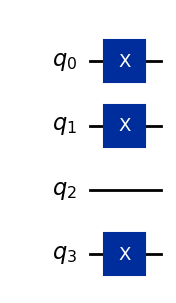

In [64]:
qc = QuantumCircuit(4)

ps = PauliString([(0, "X"), (1, "X"), (3, "X")])

append_pauli(qc, ps)
qc.draw("mpl")

**(c)**

**Check agreement with III.1 (a)**

In [65]:
sv = Statevector.from_instruction(qc)
print("Statevector :", sv.data)
probs = sv.probabilities_dict() 
print("Probabilities :", probs)

Statevector : [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
 0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
Probabilities : {np.str_('1011'): np.float64(1.0)}


Statevector agrees with III.1 (a)

Comments are from IBM Quantum learning [6].

In [66]:
backend = AerSimulator()

print(backend.name)

aer_simulator


In [67]:
## Transpile
target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)
qc_1=qc.copy()
qc_1.measure_all()
qc_isa = pm.run(qc_1)

In [68]:
sampler = Sampler(mode=backend) 
pubs = [qc_isa] # Primitive Unified Blocs, holds circuit
job = sampler.run(pubs, shots=1000) # repeats the circuit 1000 times
res = job.result()
 
counts = res[0].data.meas.get_counts()

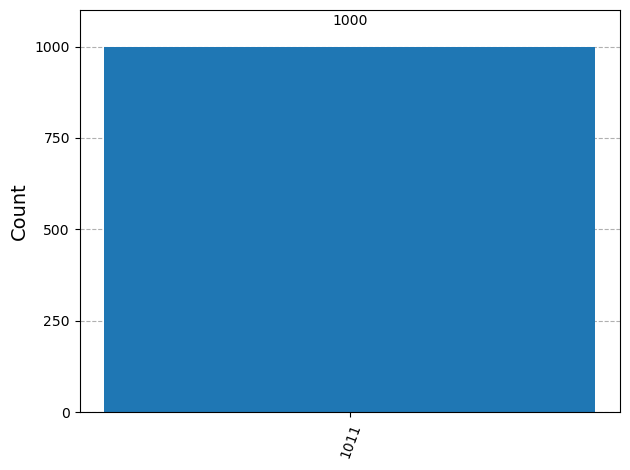

In [69]:
## Analysis

plot_histogram(counts)
#plt.hist(counts)

Aer simulator gives expected result for III.1 (a)

**Check agreement with III.1(c)**

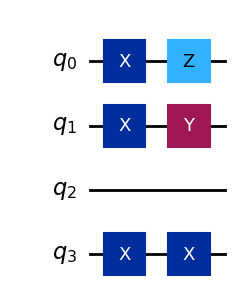

In [70]:
ps1 = PauliString([(3,"X"), (2,"I"), (1,"Y"), (0,"Z")])
append_pauli(qc, ps1)
qc.draw("mpl")

In [71]:
sv = Statevector.from_instruction(qc)
print("Statevector :", sv.data)
probs = sv.probabilities_dict() 
print("Probabilities :", probs)

Statevector : [0.+0.j 0.+1.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
Probabilities : {np.str_('0001'): np.float64(1.0)}


Statevector agrees with III.1 (c)

In [72]:
## Transpile
target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)
qc_2=qc.copy()
qc_2.measure_all()
qc_isa = pm.run(qc_2)

In [73]:
sampler = Sampler(mode=backend) 
pubs = [qc_isa] # Primitive Unified Blocs, holds circuit
job = sampler.run(pubs, shots=1000) # repeats the circuit 1000 times
res = job.result()
 
counts = res[0].data.meas.get_counts()

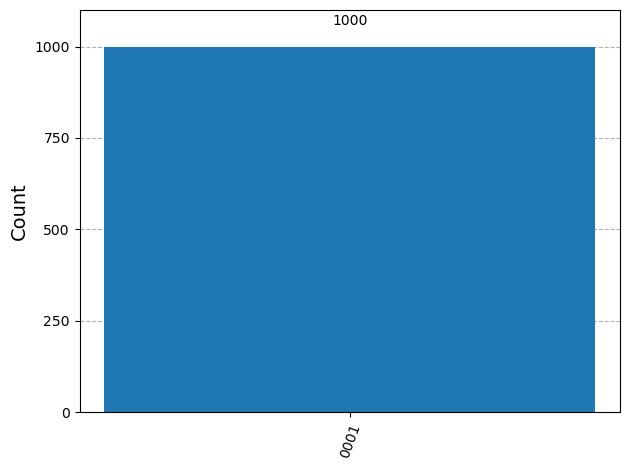

In [74]:
## Analysis

plot_histogram(counts)
#plt.hist(counts)

Aer simulator gives expected result for III.1 (c)

**Check agreement with $X_0Z_0\otimes I_1\otimes Y_2\otimes Z_3 \otimes Z_4$.**

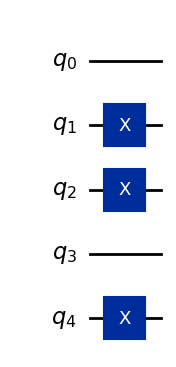

In [75]:
qc = QuantumCircuit(5)

ps = PauliString([(1, "X"), (2, "X"), (4, "X")])

append_pauli(qc, ps)

qc.draw("mpl")

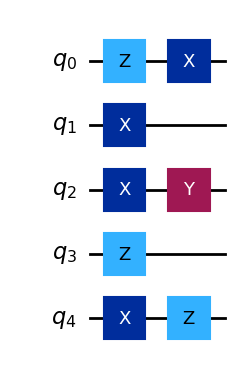

In [76]:
ps2 = PauliString([(0,"Z")])
append_pauli(qc, ps2)
ps3 = PauliString([(0,"X"),(4,"Z"), (3,"Z"), (2,"Y"), (1,"I")]) #in little-endian
append_pauli(qc, ps3)
qc.draw("mpl")

In [77]:
sv = Statevector.from_instruction(qc)
print("Statevector :", sv.data)
probs = sv.probabilities_dict() 
print("Probabilities :", probs)

Statevector : [0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+1.j
 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j
 0.+0.j 0.+0.j]
Probabilities : {np.str_('10011'): np.float64(1.0)}


Statevector agrees.

In [78]:
## Transpile
target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)
qc_2=qc.copy()
qc_2.measure_all()
qc_isa = pm.run(qc_2)

In [79]:
sampler = Sampler(mode=backend) 
pubs = [qc_isa] # Primitive Unified Blocs, holds circuit
job = sampler.run(pubs, shots=1000) # repeats the circuit 1000 times
res = job.result()
 
counts = res[0].data.meas.get_counts()

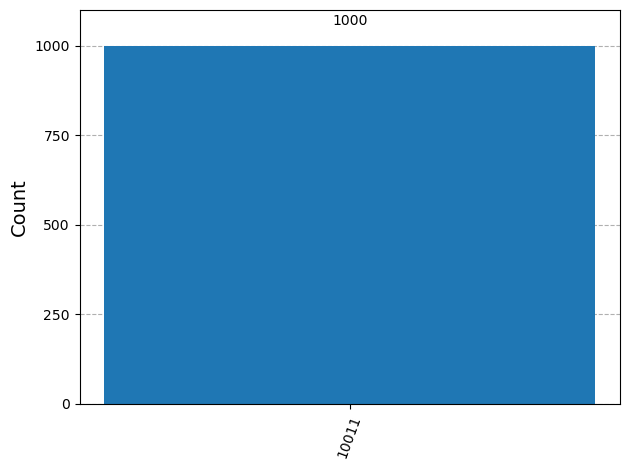

In [80]:
## Analysis

plot_histogram(counts)
#plt.hist(counts)

Aer simulator gives expected result.

#### Unitary time evolution of Pauli operators

A single Pauli string $\hat P$ is both Hermitian and unitary, so its time-evolution operator $e^{-it\hat P}$ is unitary and can be implemented as a circuit. 

For $\hat P=\hat Z_1\otimes \hat Z_2\otimes\cdots\otimes \hat Z_M$, the unitary $e^{-it\hat P}$ can be implemented by computing the parity of the $M$ qubits with a CNOT ladder, applying a single $R_z(2t)$ rotation to one qubit, and then uncomputing the parity [1]. This is verified mathematically below.

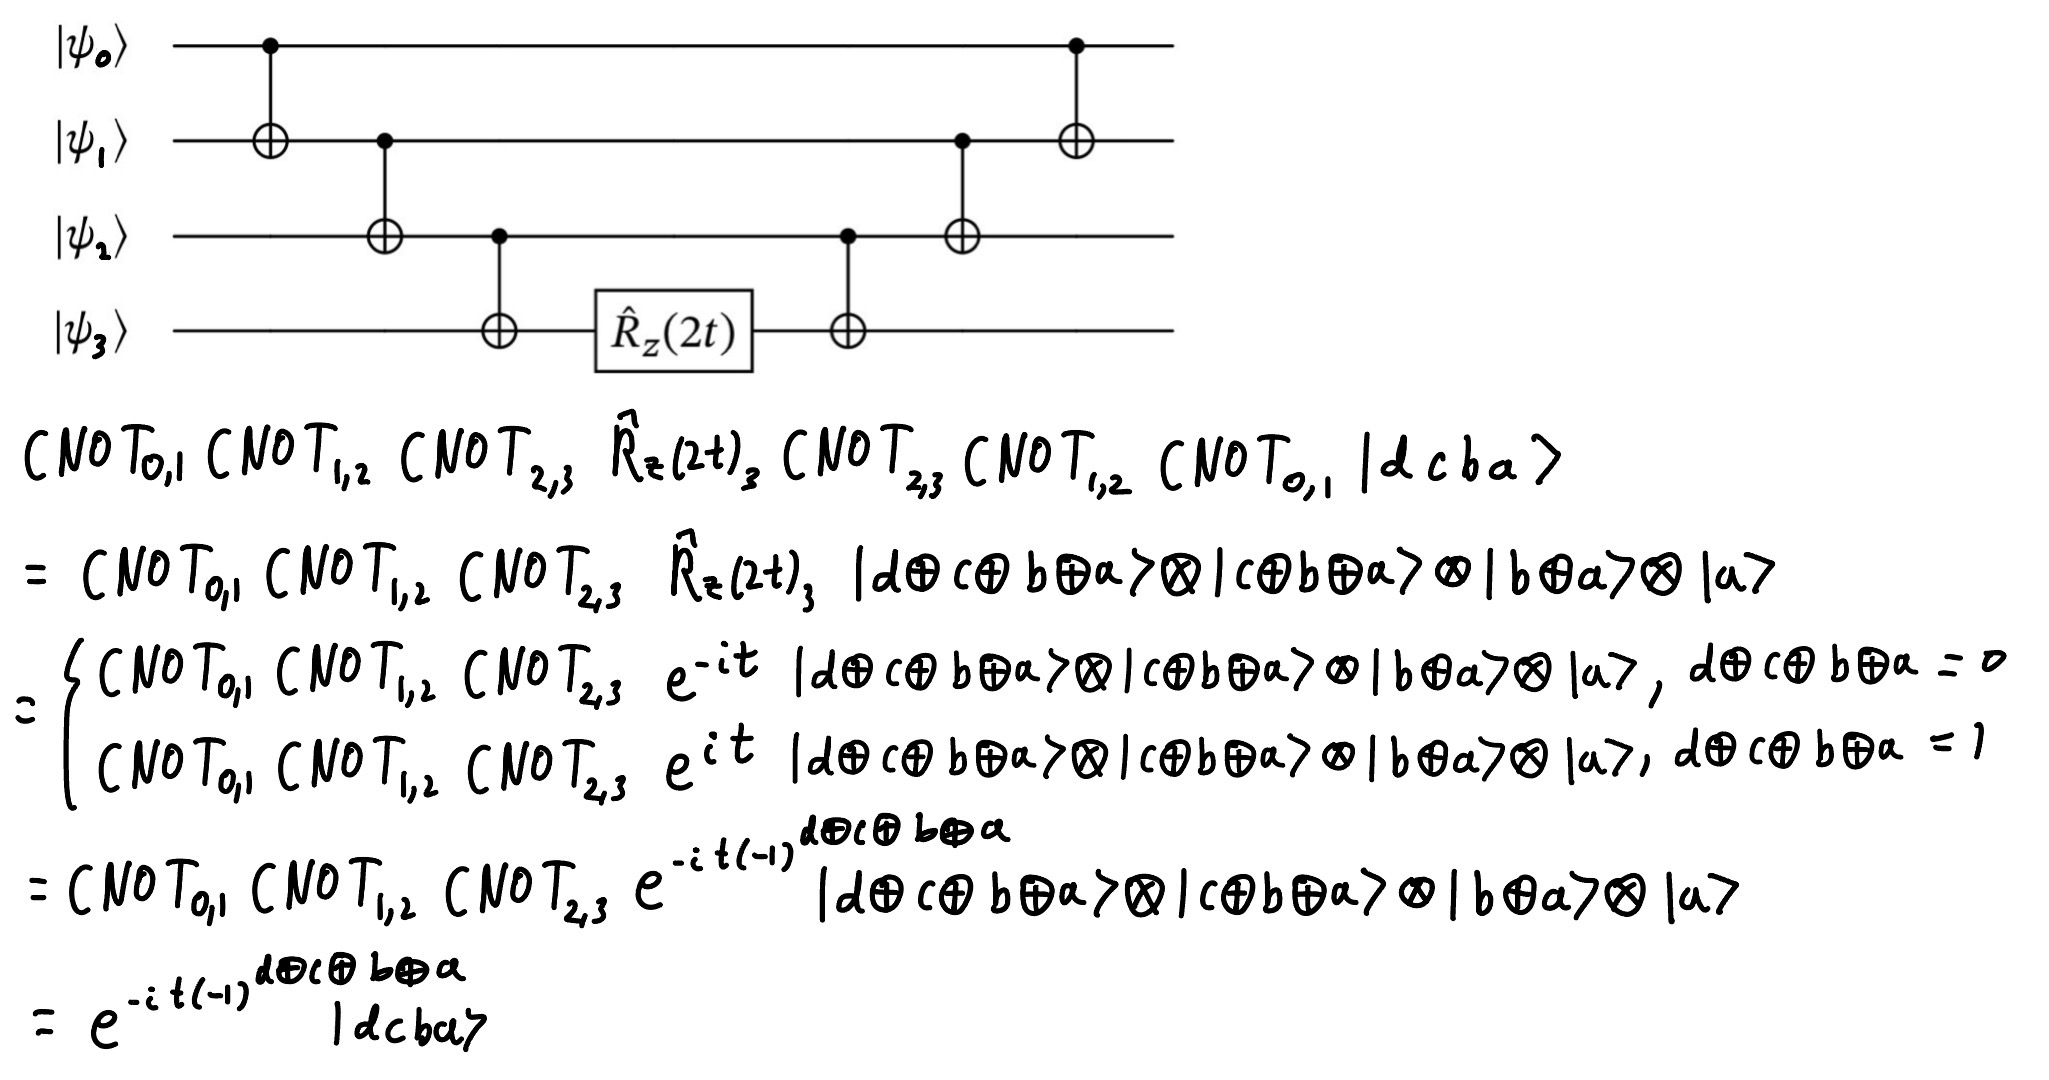

In [130]:
Image('3_3.jpg')

If $\hat P$ contains $\hat X_p$ or $\hat Y_p$ factors, each is first conjugated into $\hat Z_p$ using single-qubit basis changes,
$$
\hat X_p = \hat H_p \hat Z_p \hat H_p,\qquad
\hat Y_p = (\hat S_p \hat H_p^\dagger)\hat Z_p(\hat H_p \hat S_p^\dagger),
$$
after which the same parity - $R_z(2t)$ - uncompute pattern applies [1].

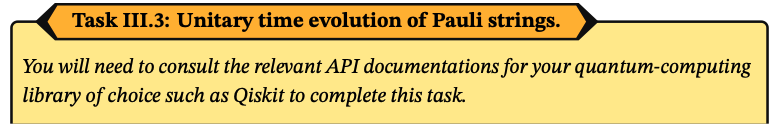

In [81]:
Image('3_3a.png')

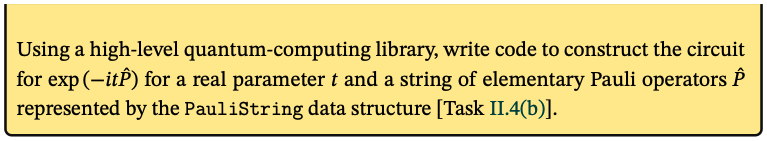

In [82]:
Image('3_3b.png')

In [84]:
def exp_it(ps, t, num_qubits):
    qop = ps.to_openfermion()
    terms = list(qop.terms.items())

    term, coeff = terms[0]
    qc = QuantumCircuit(num_qubits)

    basis_changes = [] 
    
    #involved qubits (non identity)
    involved = [p for p, n in sorted(term, key=lambda x: x[0])]
    
    #keep to uncompute
    for p, op in sorted(term, key=lambda x: x[0]):
        #sort by qubit index
        if op == "X":
            qc.h(p)
            basis_changes.append((p, "X"))
        elif op == "Y":
            qc.sdg(p) #notes have conjugation order incorrect
            qc.h(p)
            basis_changes.append((p, "Y"))
        elif op == "Z":
            basis_changes.append((p, "Z"))
            
    # cnot over involved qubits
    for i in range(len(involved) - 1):
        qc.cx(involved[i], involved[i+1])

    # Phase rotation
    qc.rz(2.0 * t, involved[-1])

    # uncompute 
    for i in reversed(range(len(involved) - 1)):
        qc.cx(involved[i], involved[i+1])

    #undo basis changes
    for p, op in reversed(basis_changes):
        if op == "X":
            qc.h(p)
        elif op == "Y":
            qc.h(p)
            qc.s(p)
        elif op == "Z":
            pass

    return qc

Check if the the circuit for $\exp[-it(\hat Z_1 \otimes\hat X_2 \otimes\hat Y_3 \otimes\hat Z_4)]$ is correct.

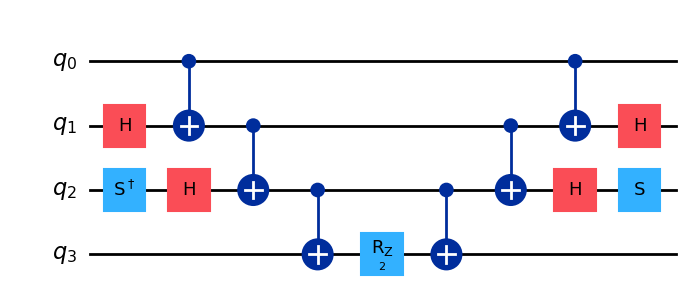

In [85]:
ps = PauliString([(0,"Z"),(1,"X"), (2,"Y"), (3,"Z")])
t = 1
qc = exp_it(ps, t, num_qubits=4)
qc.draw("mpl")

Circuit as expected.

See if the Identity is correctly accounted for, with $\exp[-it(\hat Z_1 \otimes\hat I_2 \otimes\hat Y_3 \otimes\hat Z_4)]$.

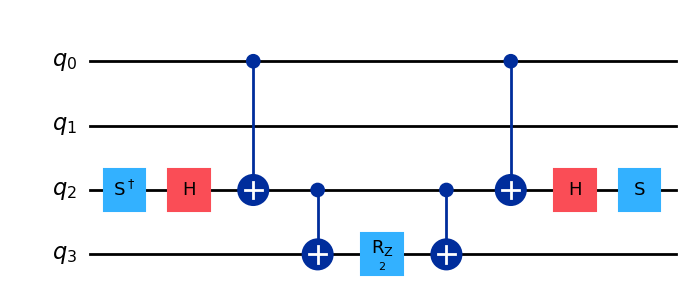

In [140]:
ps1 = PauliString([(0,"Z"),(1,"I"), (2,"Y"), (3,"Z")])
t = 1
qc = exp_it(ps1, t, num_qubits=4)
qc.draw("mpl")

Answer as expected, without CNOT on qubit 1.

#### Trotterisation

A general qubit operator is a sum of $K$ Pauli strings,
$$
\hat Q=\sum_{k=0}^{K-1} c_k \hat P_k,
$$
which is Hermitian but not unitary. Quantum simulation requires the unitary time evolution $e^{-it\hat Q}$, but since the Pauli string terms $\hat P_k$ do not necessarily commute,
$$
e^{-it\sum_k c_k\hat P_k}\neq \prod_k e^{-it c_k \hat P_k}.
$$
The Trotter-Suzuki formulas approximate $e^{-it\hat Q}$ as follows.

First-order with Trotter number $r$:
$$
e^{-it\hat Q}= \left[\prod_{k=0}^{K-1}\exp\left(-i\frac{t}{r}c_k\hat P_k\right)\right]^r+ \mathcal{O}(t^2/r).
$$
Second-order Trotter-Suzuki:
$$
e^{-it\hat Q}= \left[\prod_{k=0}^{K-1}\exp\left(-i\frac{t}{2r}c_k\hat P_k\right)
\prod_{k=0}^{K-1}\exp\left(-i\frac{t}{2r}c_{K-k-1}\hat P_{K-k-1}\right)\right]^r+ \mathcal{O}(t^3/r^2).
$$
Increasing $r$ reduces the approximation error but increases circuit depth [1].

The indexing for the second-order Trotter-Suzuki formula is verified below, noting that for this example the first $q$ has index $1$, like in the manual.

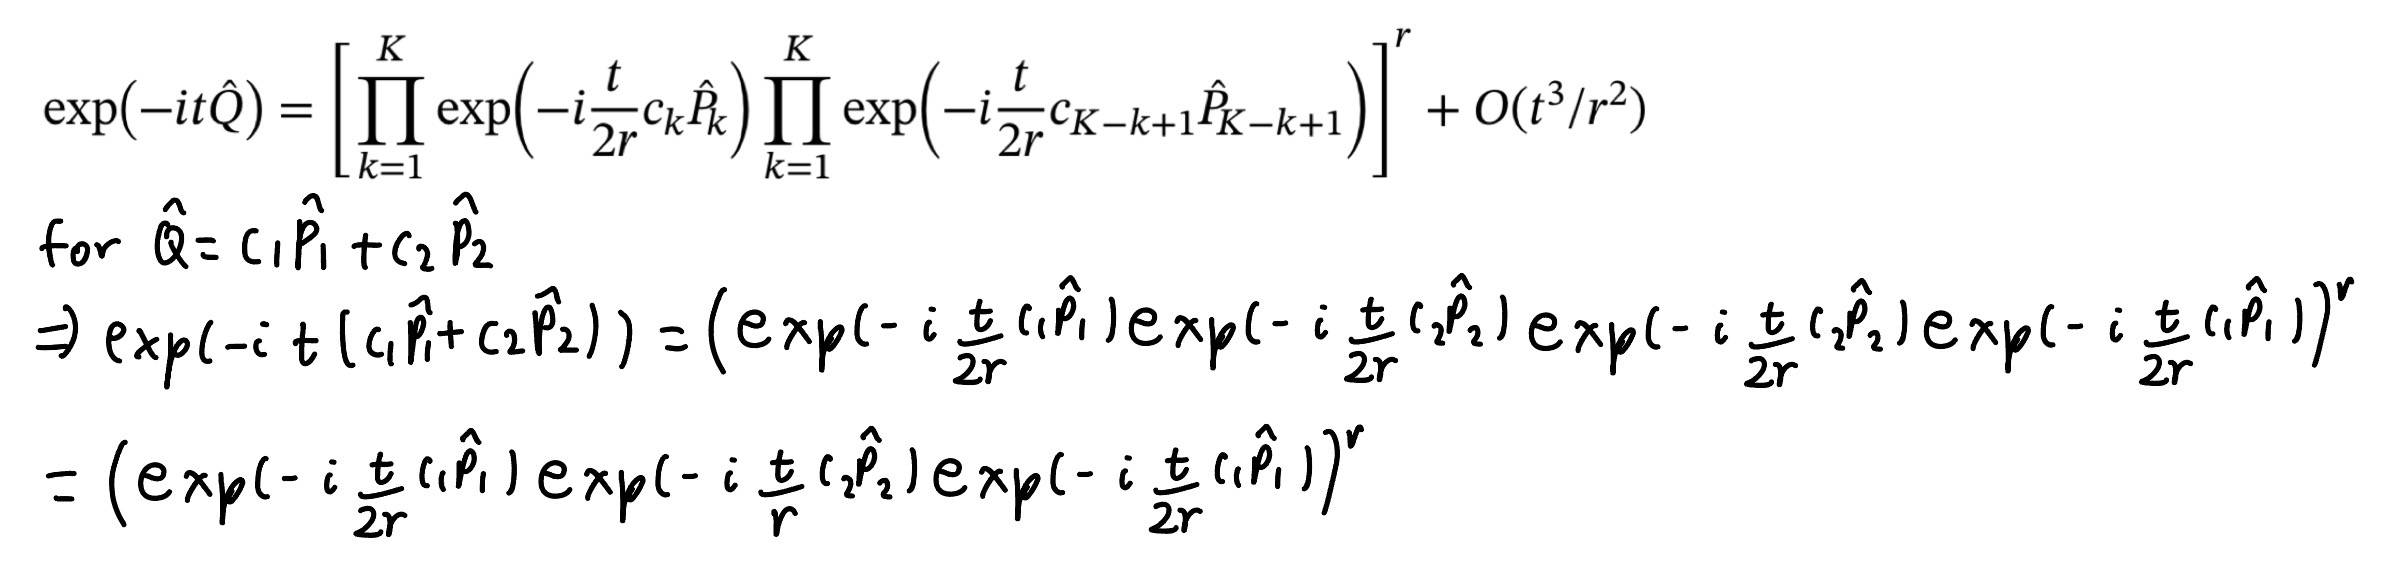

In [131]:
Image('3_4.jpg')

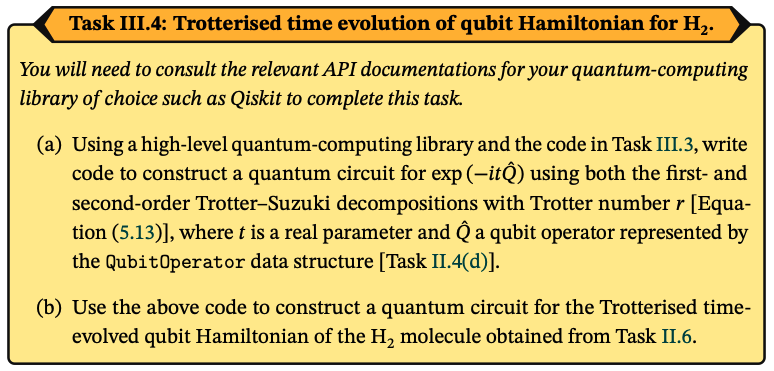

In [84]:
Image('3_4.png')

**(a)**

In [121]:
def trotter_first_order(Q, t, r, num_qubits):
    qc = QuantumCircuit(num_qubits)
    
    terms = []
    for term, coeff in Q.to_openfermion().terms.items():
        ps = PauliString(list(term))
        terms.append((coeff, ps))
    terms.sort(key=lambda x: str(x[1])) #deterministic term order
    

    dt = t / r
    for _ in range(r):
        for ck, Pk in terms:
            qc.compose(exp_it(Pk, (dt * ck).real, num_qubits), inplace=True)
            # modify rather than new circuit
    return qc

def trotter_second_order(Q, t, r, num_qubits):
    qc = QuantumCircuit(num_qubits)
    terms = []
    for term, coeff in Q.to_openfermion().terms.items():
        ps = PauliString(list(term))
        terms.append((coeff, ps))

    terms.sort(key=lambda x: str(x[1]))
    dt = t / r

    for _ in range(r):
        for ck, Pk in terms:
            qc.compose(exp_it(Pk, (dt * ck/2).real, num_qubits), inplace=True)

        for ck, Pk in reversed(terms):
            qc.compose(exp_it(Pk, (dt * ck/2).real, num_qubits), inplace=True)

    return qc

Confirm whether the circuit from III.3 is correctly reproduced.

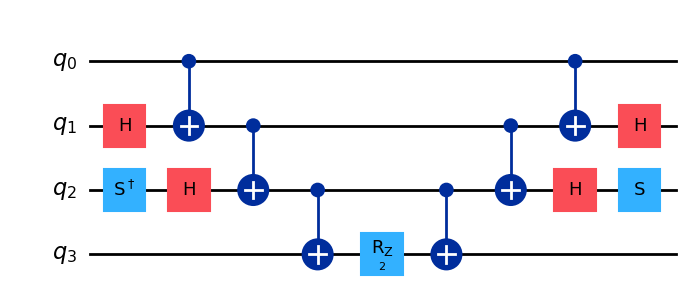

In [122]:
ps = PauliString([(0,"Z"),(1,"X"), (2,"Y"), (3,"Z")])
t = 1
qc=trotter_first_order(ps,t,1,4)
qc.draw("mpl")

Circuit as desired. Now confirm if second order is correct.

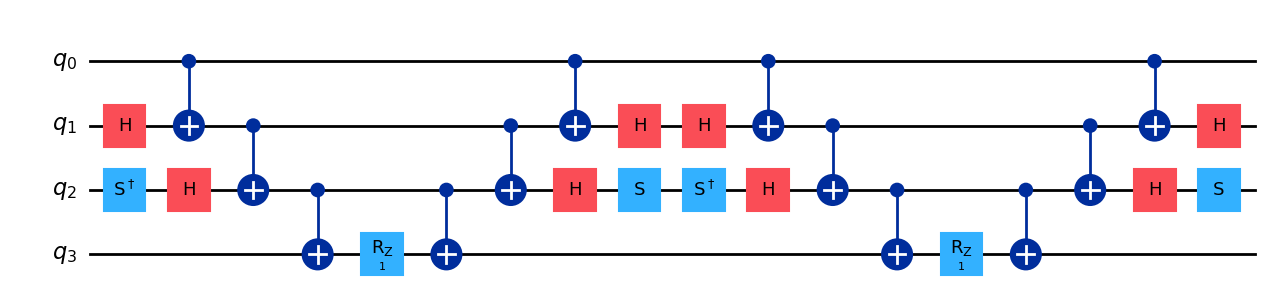

In [123]:
qc=trotter_second_order(ps,t,1,4)
qc.draw("mpl")

Circuit as desired.

**(b)**

$H_2$ molecule.

In [124]:
#useful for final module
def ps_convert(H_q):
    ops = []
    for term, coeff in H_q._qop.terms.items():
        if term:
            ops.append((coeff.real, PauliString(list(term))))
    return QubitOperator(ops)
H2_q=ps_convert(H_q)
print(H2_q)


-0.049197645871367546 [X0 X1 Y2 Y3] +
0.049197645871367546 [X0 Y1 Y2 X3] +
0.049197645871367546 [Y0 X1 X2 Y3] +
-0.049197645871367546 [Y0 Y1 X2 X3] +
0.13716572937099492 [Z0] +
0.1566006248823794 [Z0 Z1] +
0.10622904490856078 [Z0 Z2] +
0.15542669077992832 [Z0 Z3] +
0.13716572937099483 [Z1] +
0.15542669077992832 [Z1 Z2] +
0.10622904490856078 [Z1 Z3] +
-0.13036292057109045 [Z2] +
0.1632676867356434 [Z2 Z3] +
-0.13036292057109042 [Z3]


First Order:


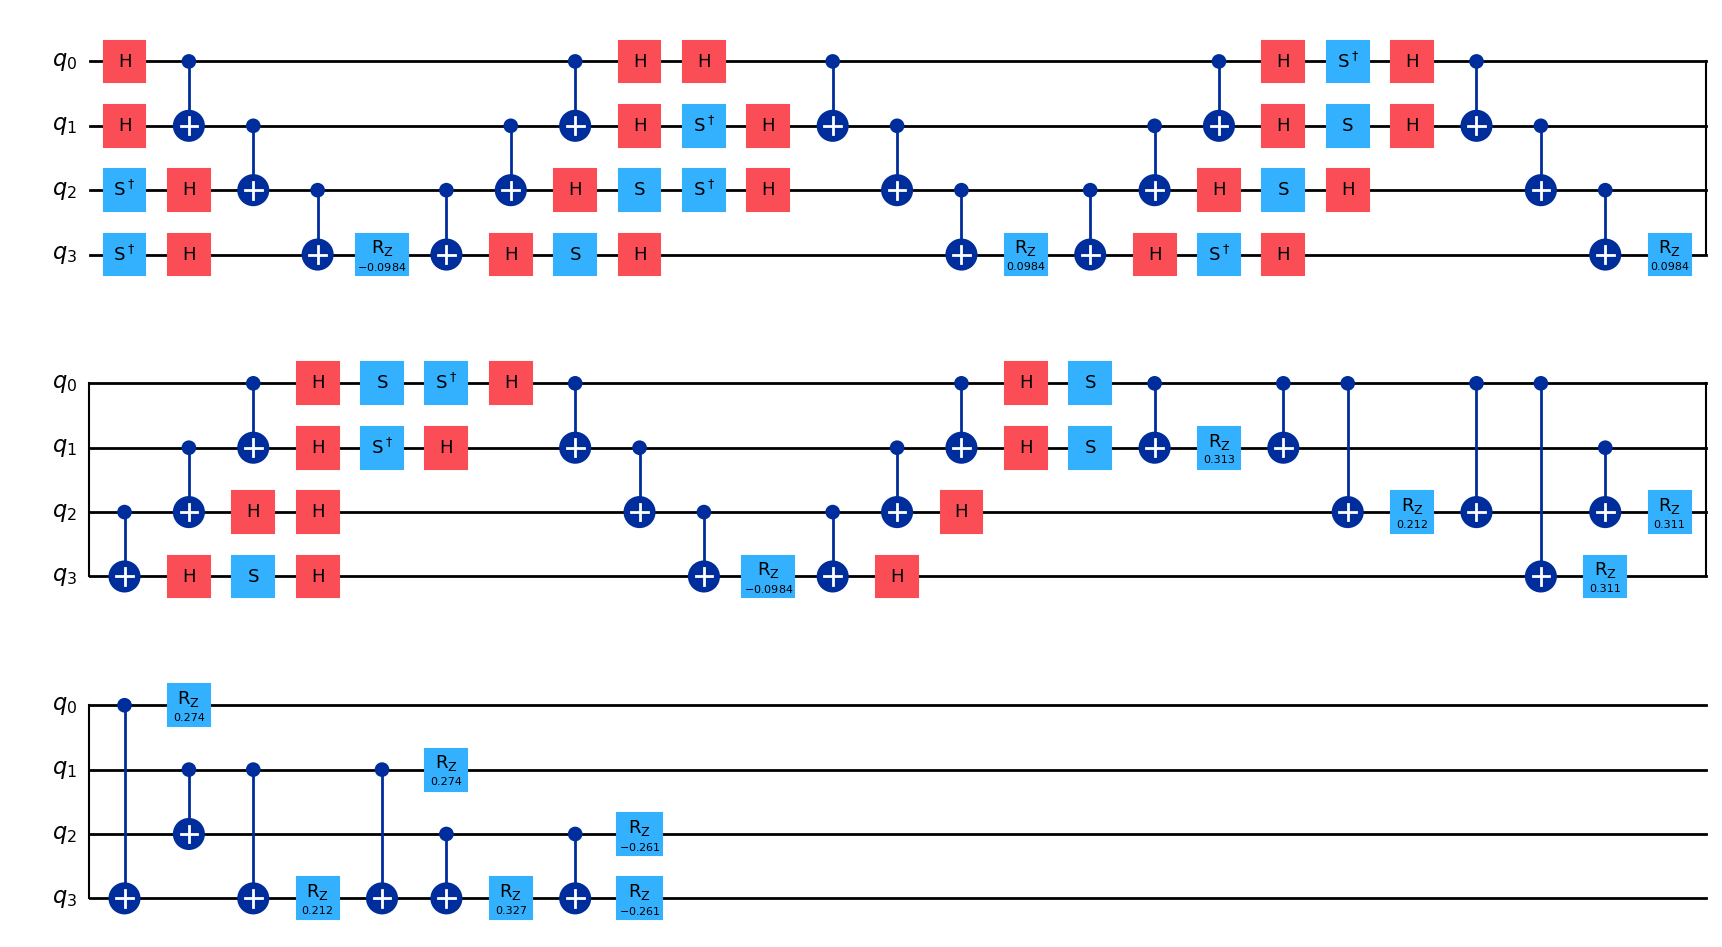

In [125]:
t = 1
r = 1
num_qubits = 4

qc_1st = trotter_first_order(H2_q, t, r, num_qubits)
qc_2nd = trotter_second_order(H2_q, t, r, num_qubits)
print("First Order:")
qc_1st.draw("mpl")

All terms appear as expected, but the one body $Z_i$ terms end up at the end because the conversion rebuilds the operator and can change the term insertion order. Since the Pauli terms do not all commute, different orderings correspond to different first order Trotter approximations, with local error $\mathcal{O}(\Delta t^2)$, which is expected. As long as a single ordering is fixed and used consistently, it is meaningful to compare results across runs (noting that different orderings can have different constants in the error).

Second Order:


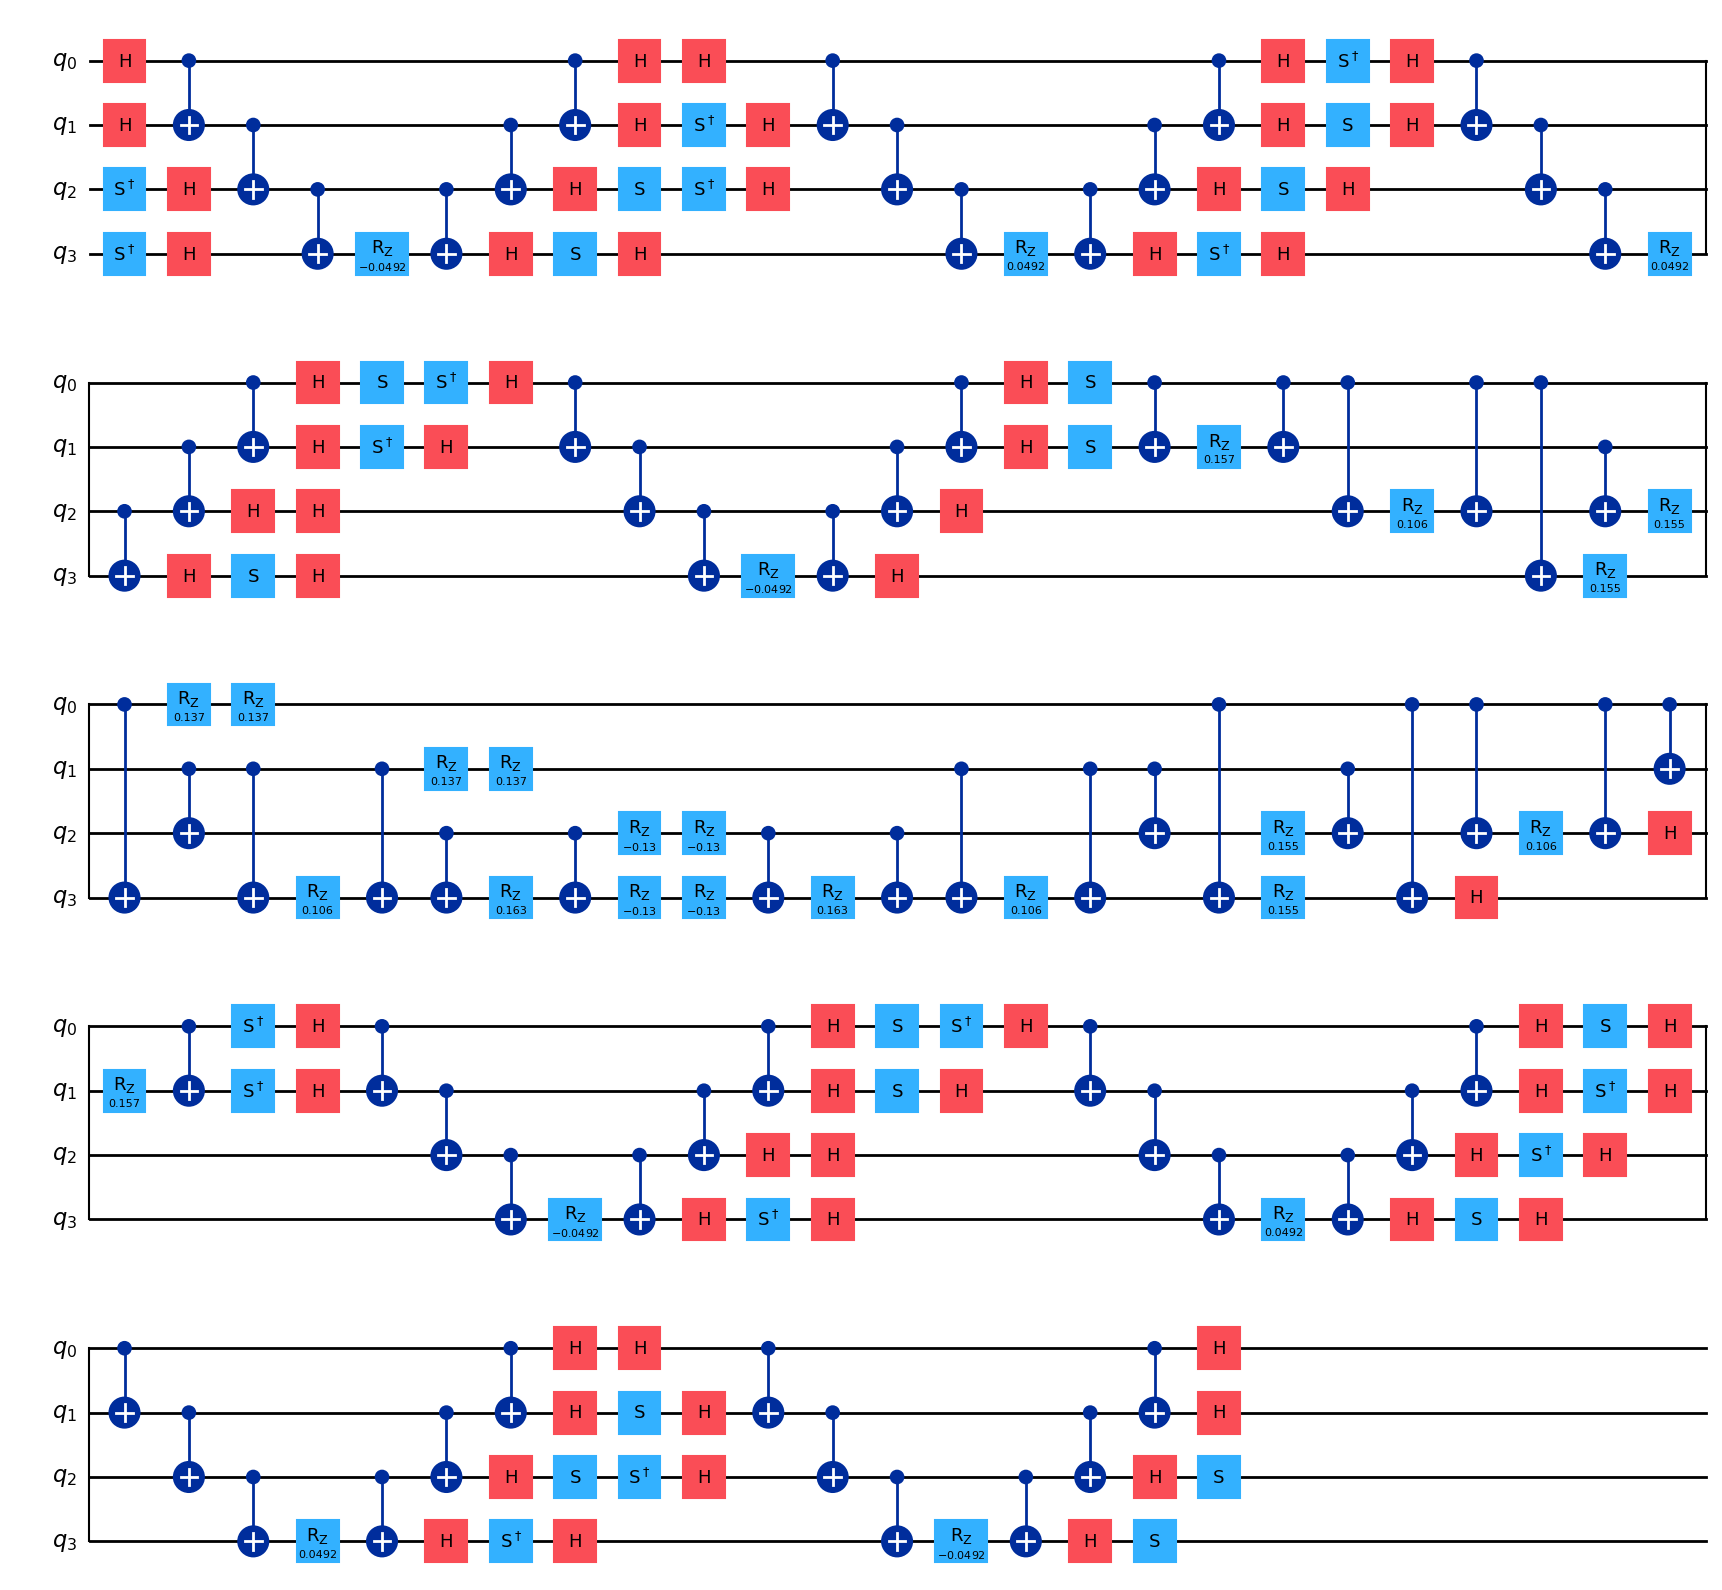

In [126]:
print("Second Order:")
qc_2nd.draw("mpl")

### Discussion Questions

*What is the maximum number of qubits that your computer can handle for state-
vector simulations? What aspects of your computer (e.g. CPUs or RAM) determine
this? How does this answer change if you change the numerical data type of
state-vector elements (e.g. single- or double-precision complex numbers)?*

Complex128 is double precision complex and uses 16 bytes per amplitude, and Complex64 is single precision complex and uses 8 bytes per amplitude [7]. My laptop has 24GB (~22.35 GiB) of ram which means with Complex128 I can use 30 qubits $\left(22.35\cdot2^{30}\approx2^{34.48}=16\cdot2^{30.48}\right)$, and with Complex64 I can use 31 qubits $\left(2^{34.48}=8\cdot2^{31.48}\right)$ [8].


*Can you give a bound for the depth of the circuit for $\text{exp}(−it\hat{P})$ in terms of the length of $\hat{P}$?*

Pauli of length $l$ ($l$ non-identity Paulis) has circuit depth that scales linearly in $l$. Parity compute uses $l-1$ CNOT layers, then one $R_z$, then $l-1$ layers to uncompute, worst case $Y$ basis change requires $4$ layers $\Rightarrow\text{depth}\leq2(l-1)+1+4=2l+3$.

*How does the depth of the circuit for $\text{exp}(−it\hat{P})$ vary with the Trotter number $r$?
What about the numerical errors arising from the Trotter–Suzuki decompositions?
Can you quantify this numerically for a simple $\hat{Q}$?*

For $\hat{Q}=\sum_{k=0}^{K-1}c_k\hat{P}_k$, first order $\text{depth}\approx r\sum_{k=0}^{K-1}\text{depth}\left[\text{exp}(−i\frac{t}{r}c_k\hat{P}_k)\right]\approx r\sum_{k=0}^{K-1}(2l_k+3)$, and for second order, $\text{depth}\approx 2r\sum_{k=0}^{K-1}(2l_k+3)$.

Error scales as shown below, with example $\hat{Q}=\hat{X}_0+\hat{Z}_0$. Noting that if $A$ is Hermitian and has eigenvalue equation $Av_i=\lambda_i v_i$ then $A=V\Lambda V^\dagger$ with $\Lambda=\text{diag}(\lambda_i)$, and $V=[v_1\cdots v_n]$ (for $n$ eigenvectors). This means that $e^{-itA}=e^{-itV\Lambda V^\dagger}=Ve^{-it\Lambda}V^\dagger=V\text{diag}\left(e^{-it\lambda_i}\right)V^\dagger$ (as $V^\dagger V=I$, and $\Lambda$ is diagonal).

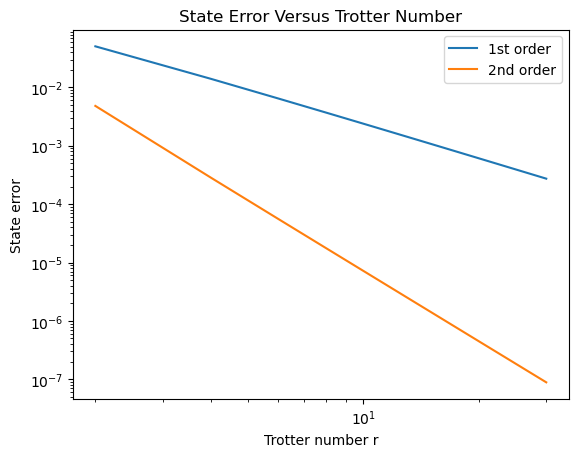

In [133]:
t = 1
rs = np.arange(2, 31, 2)
# exact
evals, evecs = np.linalg.eigh(X +Z)
Ue = evecs @ np.diag(np.exp(-1j * t* evals)) @ evecs.conj().T

# trotterization
Xps = PauliString([(0,"X")])
Zps = PauliString([(0,"Z")])
Q = QubitOperator([(1.0,Xps), (1.0,Zps)])


psi0 =Statevector.from_label("0")
#input state
err1, err2 = [], []
for r in rs:
    qc1 = trotter_first_order(Q, t,r,num_qubits=1)
    qc2 = trotter_second_order(Q, t,r,num_qubits=1)

    psi1 =psi0.evolve(qc1).data
    psi2 =psi0.evolve(qc2).data
    
    err1.append(1 -np.abs(np.vdot(Ue @ np.array([1,0],complex), psi1))**2)
    #Ue|0>, inner product of this with psi1
    err2.append(1 -np.abs(np.vdot(Ue @ np.array([1,0],complex), psi2))**2)

plt.loglog(rs, err1, label="1st order")
plt.loglog(rs, err2, label="2nd order")
plt.xlabel("Trotter number r")
plt.ylabel(r"State error")
plt.title("State Error Versus Trotter Number")
plt.legend()
plt.show()

First order has global operator error $\mathcal{O}(t^2/r)\Rightarrow$ state infidelity scales as $\approx \mathcal{O}(1/r^2)$ (for fixed $t$), whereas second order has global operator error $\mathcal{O}(t^3/r^2)$ so state infidelity scales as $\approx \mathcal{O}(1/r^4)$. $\Rightarrow$ Expect 1st order to have slope $\approx-2$, and 2nd order to have slope $\approx-4$.

In [139]:
m1, b1 = np.polyfit(np.log(rs), np.log(err1), 1)
m2, b2 = np.polyfit(np.log(rs), np.log(err2), 1)

print("slope (1st order):", m1)
print("slope (2nd order):", m2)

slope (1st order): -1.9394583122114095
slope (2nd order): -4.0196902494381455


Answer as expected.

## Module 3 Logbook 

This laboratory focused on simulation in quantum computing, both as classical emulation of quantum circuits and as time evolution implemented with qubits. The first part considered classical state vector simulation. A computational basis bitstring was mapped to an $M$ index complex tensor representing the full $2^M$ dimensional state. This showed how amplitudes and measurement frequencies are stored and why memory grows exponentially with qubit number.

Single Pauli strings were then applied directly to the state vector using tensor contractions with the Pauli matrices reproducing simple quantum circuits only using linear algebra. Frequencies obtained from $|V_{i_0i_1\cdots i_{M-1}}|^2$ matched the expected computational basis outcomes, which confirmed that the indexing and contraction logic were correct.

The same tasks were repeated using Qiskit. Circuits were initialized to chosen bitstrings and layers of Pauli gates were appended from a PauliString description. Statevector simulation and shot based sampling with the Aer simulator gave the same results as the manual tensor approach.

The next part considered unitary time evolution under a Pauli string $\exp(-it\hat P)$. Basis changes converted $\hat{X}$ and $\hat{Y}$ operators to $\hat{Z}$, followed by parity accumulation with CNOT ladders, a single $R_z(2t)$ rotation, and uncomputation.

Finally, Trotterisation was used to approximate time evolution generated by a sum of Pauli strings. First and second order Trotter-Suzuki formulas were implemented and applied to the $H_2$ qubit Hamiltonian. Increasing the Trotter number reduced approximation error but increased circuit depth, which would increase hardware noise on current hardware. A one qubit example with $\hat Q = \hat{X}+\hat{Z}$ was used to study the error scaling by comparing Trotterized evolution to the exact solution.

# Part IV
## Obtaining Electronic Energies

#### Quantum phase estimation

The electronic Hamiltonian $\hat H$ is Hermitian but not unitary, so the unitary operator $\hat U(t)=e^{-it\hat H}$ is used instead of $\hat H$ itself. If $\hat H\Psi_j=E_j\Psi_j$, then $\Psi_j$ is also an eigenstate of $\hat U(t)$ with eigenvalue $e^{-itE_j}$, so estimating the phase of $\hat U(t)$ can be used to find the energy $E_j$.

More generally, for a unitary $\hat U$ with
$$
\hat U|\Psi_j\rangle = e^{2\pi i\theta_j}|\Psi_j\rangle,\qquad \theta_j\in[0,1),
$$
quantum phase estimation (QPE) uses an $n$-qubit estimation register to infer the binary fraction $\theta_j\approx \overline{0.b_1b_2\cdots b_n}\equiv\frac{\overline{\theta}_j}{2^n}, \quad b_i \in \{0,1\}$.

Example for $\theta_j=0.5$ is shown below.

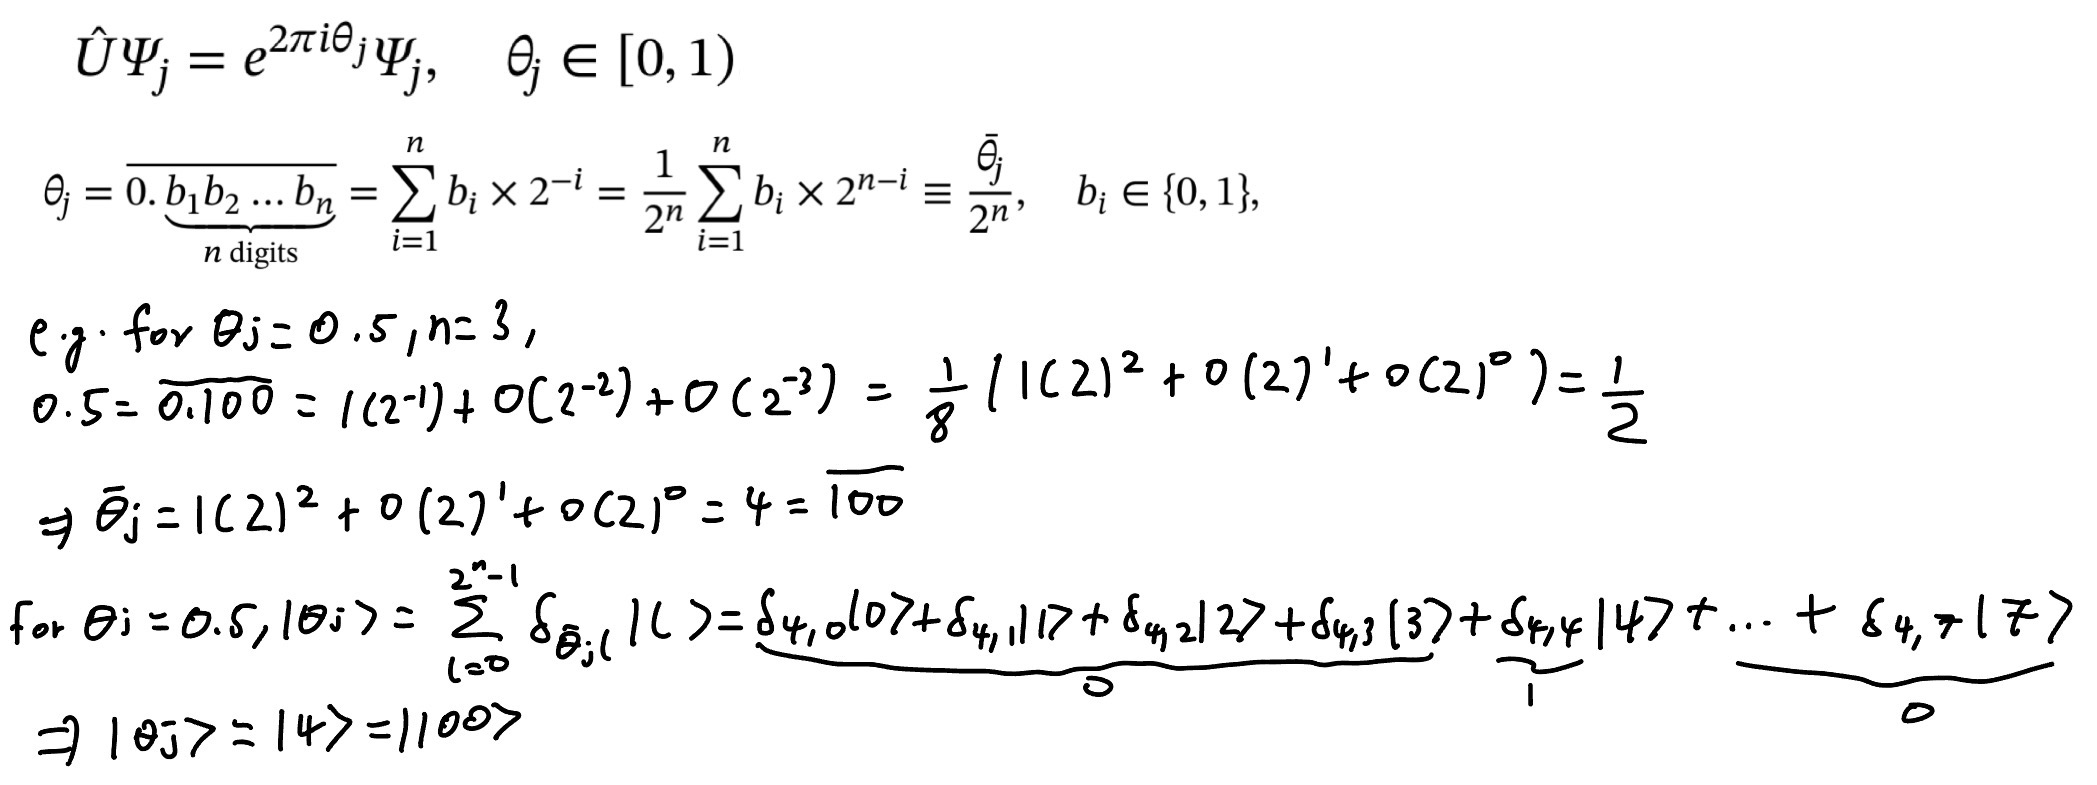

In [141]:
Image('6_a.jpg')

The QPE circuit prepares a uniform superposition on the estimation register. Controlled powers $\hat U^{2^m}$ are applied to the state register (initialised as $|\Psi_j\rangle$), conditioned on each estimation qubit ($m=0,1,\cdots,n-1$). A $\text{QFT}^{-1}$ is then applied, noting that $\text{QFT}|\theta_j\rangle=\frac{1}{\sqrt{2^n}}\sum_{k=0}^{2^n-1} e^{2\pi i \theta_j k}|k\rangle$. The estimation register then becomes the state $|\theta_j\rangle$.

If the state register is initialised in a guess state
$$
|\Psi_{\rm guess}\rangle=\sum_j c_j|\Psi_j\rangle,
$$
then outcome $\theta_j$ accurate to $n$ binary places is obtained with probability $|c_j|^2$, so good overlap with the desired eigenstate is required [1].

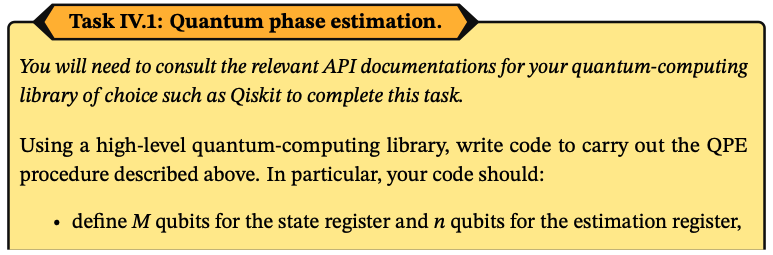

In [93]:
Image('4_1a.png')

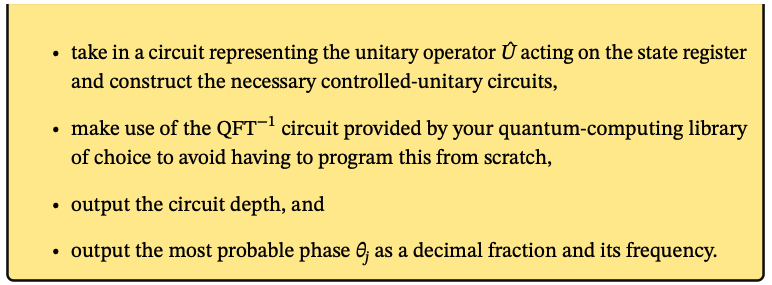

In [94]:
Image('4_1b.png')

In [246]:
def build_qpe(U,n):
    M= U.num_qubits
    est= QuantumRegister(n, "est")
    state= QuantumRegister(M, "state")
    c= ClassicalRegister(n, "c")
    qc= QuantumCircuit(state, est, c)
    
    qc.h(est)
    # hadamards to estimation register
    Ug = U.to_gate(label="U")
    for m in range(n):
        Upow = Ug.power(2**m).control(1)
        #1 control qubit
        qc.append(Upow, [est[m]] + list(state))
        #[control, state[0],..., state[M-1]]

    qc.append(QFTGate(n).inverse(), est)
    qc.measure(est, c)
    return qc

backend=AerSimulator()
def run_qpe(U, n, prep_state, shots,draw_circuit=False,print_=False):
    M= U.num_qubits
    qc= build_qpe(U, n)

    prep = QuantumCircuit(n + M, n)
    #n+m qubits, n classical bits
    prep.compose(prep_state, qubits=list(range(0,M)), inplace=True)
    # state register first
    qc = prep.compose(qc)
    if draw_circuit:
        print(qc.draw(output="text"))

    transp = transpile(qc,backend)
    
    t0 = time.perf_counter()
    
    counts = backend.run(transp, shots=shots).result().get_counts()

    time_taken = time.perf_counter() - t0
    
    count, bitstr = max((c, b) for b, c in counts.items())
    freq = count / shots
    #bitstring with biggest count
    theta = int(bitstr.replace(" ", ""), 2) / (2**n)
    #base 2
    if print_:
        print("Transpiled circuit depth:", transp.depth())
        print("Time taken (s):", time_taken)
        print("Most probable theta:", theta)
        print("Frequency:", freq)

    return qc, counts, transp.depth(), time_taken,theta

Does this produce the same result as the handwritten result for $\theta_j=0.5$?

In [247]:
theta_true = 1/2
U = QuantumCircuit(1)
U.p(2*np.pi*theta_true, 0)

prep = QuantumCircuit(1)
#P|1>=e^(i phi) |1>
prep.x(0)

run_qpe(U, n=3, prep_state=prep, shots=5000,draw_circuit=True,print_=True)

     ┌───┐┌──────────────────┐┌──────────────────┐┌──────────────────┐»
q_0: ┤ X ├┤ circuit-486419^1 ├┤ circuit-486419^2 ├┤ circuit-486419^4 ├»
     ├───┤└────────┬─────────┘└────────┬─────────┘└────────┬─────────┘»
q_1: ┤ H ├─────────■───────────────────┼───────────────────┼──────────»
     ├───┤                             │                   │          »
q_2: ┤ H ├─────────────────────────────■───────────────────┼──────────»
     ├───┤                                                 │          »
q_3: ┤ H ├─────────────────────────────────────────────────■──────────»
     └───┘                                                            »
c: 3/═════════════════════════════════════════════════════════════════»
                                                                      »
«                         
«q_0: ────────────────────
«     ┌─────────┐┌─┐      
«q_1: ┤0        ├┤M├──────
«     │         │└╥┘┌─┐   
«q_2: ┤1 qft_dg ├─╫─┤M├───
«     │         │ ║ └╥┘┌─┐
«q_3: ┤2        ├─╫

(<qiskit.circuit.quantumcircuit.QuantumCircuit at 0x3564790d0>,
 {'100': 5000},
 7,
 0.0017671660025371239,
 0.5)

Good agreement, and circuit looks as expected.

Confirm for $\theta_j=\frac{3}{8}$.

In [248]:
theta_true = 3/8
U = QuantumCircuit(1)
U.p(2*np.pi*theta_true, 0)

prep = QuantumCircuit(1)
#P|1>=e^(i phi) |1>
prep.x(0)

run_qpe(U, n=3, prep_state=prep, shots=5000,draw_circuit=True,print_=True)

     ┌───┐┌──────────────────┐┌──────────────────┐┌──────────────────┐»
q_0: ┤ X ├┤ circuit-486436^1 ├┤ circuit-486436^2 ├┤ circuit-486436^4 ├»
     ├───┤└────────┬─────────┘└────────┬─────────┘└────────┬─────────┘»
q_1: ┤ H ├─────────■───────────────────┼───────────────────┼──────────»
     ├───┤                             │                   │          »
q_2: ┤ H ├─────────────────────────────■───────────────────┼──────────»
     ├───┤                                                 │          »
q_3: ┤ H ├─────────────────────────────────────────────────■──────────»
     └───┘                                                            »
c: 3/═════════════════════════════════════════════════════════════════»
                                                                      »
«                         
«q_0: ────────────────────
«     ┌─────────┐┌─┐      
«q_1: ┤0        ├┤M├──────
«     │         │└╥┘┌─┐   
«q_2: ┤1 qft_dg ├─╫─┤M├───
«     │         │ ║ └╥┘┌─┐
«q_3: ┤2        ├─╫

(<qiskit.circuit.quantumcircuit.QuantumCircuit at 0x35634b490>,
 {'011': 5000},
 16,
 0.002048792001005495,
 0.375)

Good agreement.

#### Hamiltonian eigenvalues from quantum phase estimation

When QPE is applied to $\hat U(t)=e^{-it\hat H}$, an eigenstate $\Psi_j$ gives an eigenvalue phase
$$
e^{-itE_j}=e^{2\pi i\theta_j},\qquad \theta_j\in[0,1).
$$
Phases are defined modulo $2\pi$, so the energy is only determined up to an integer branch,
$$
E_j=-\frac{2\pi}{t}\,(\theta_j+m),\qquad m\in\mathbb Z^{0+}, t\in\mathbb R^+,
$$
with $m$ restricted to non-negative integers and $t>0$ to ensure $E_j \le 0$.
To obtain a unique $E_j$, energy bounds $E_{j,\min}\le E_j<E_{j,\max}$ are chosen and $t$ is set so that a single branch interval has the same width as the allowed energy range:
$$
\frac{2\pi}{t}=E_{j,\max}-E_{j,\min}.
$$
With this choice, each measured $\theta_j$ corresponds to a unique integer $m$ such that $E_j$ is in the range $[E_{j,\min},E_{j,\max})$ [1].

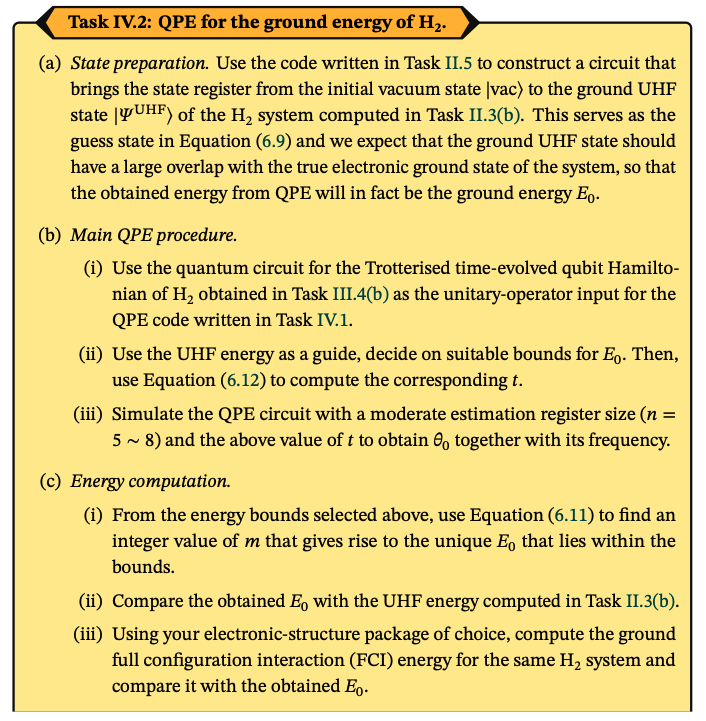

In [249]:
Image('4_2a.png')

**(a)**

Occupied orbitals from II.3(b).

In [250]:
atom = """
H 0 0 0
H 0 0 1
"""
C_a, C_b, labels, (occ_a, occ_b),E_uhf = uhf_mos(atom, "sto-3g")
print("Occupied alpha sites =", occ_a)
print("Occupied beta sites =", occ_b)

Occupied alpha sites = [1. 0.]
Occupied beta sites = [1. 0.]


In [251]:
k_uhf = (1, 1, 0, 0)
ps = occupation_to_paulistring(k_uhf)
prep_state = QuantumCircuit(4)
append_pauli(prep_state, ps)      

print(prep_state)

     ┌───┐
q_0: ┤ X ├
     ├───┤
q_1: ┤ X ├
     └───┘
q_2: ─────
          
q_3: ─────
          


Produces $|0011\rangle$, as desired.

**(b)**

**(ii)**

Picking suitable energy bounds is highly non-trivial. One practical choice is to use the Hartree-Fock energy as an upper bound. Since Hartree-Fock minimizes the energy within a restricted variational space, the variational principle ensures that $E_{\text{HF}}$ is an upper bound to the exact ground state energy of the Hamiltonian [9]. In the same finite orbital basis, full configuration interaction (FCI) gives the exact ground state energy of the Hamiltonian in that basis, so $E_0 = E_{\text{FCI}}  \le E_{\text{HF}}$ [10]. To allow for small numerical error and make sure the true energy is within the interval, $E_{\min}$ is taken as $1.001E_{\text{FCI}}$.

In [270]:
print("UHF total energy =", E_uhf)
Emax=E_uhf

UHF total energy = -1.0661086493179366


Full configuration interaction energy calculation [11].

In [271]:
mol = gto.M(atom=atom, basis=basis,unit="Angstrom",charge=0,spin=0,verbose=0)
mf = scf.UHF(mol).run() #unrestricted works

cisolver = fci.FCI(mol, mf.mo_coeff)
EFCI=cisolver.kernel()[0]
Emin=1.001*EFCI

print("FCI energy =", EFCI)

FCI energy = -1.1011503302326187


$t$ can now be found with $E_\text{max}=E_\text{HF}$, and $E_\text{min}=1.001*E_{\text{FCI}}$.

In [272]:
t=2*np.pi/(Emax-Emin)
print("t =", t)

t = 173.84319630642253


**(i)**

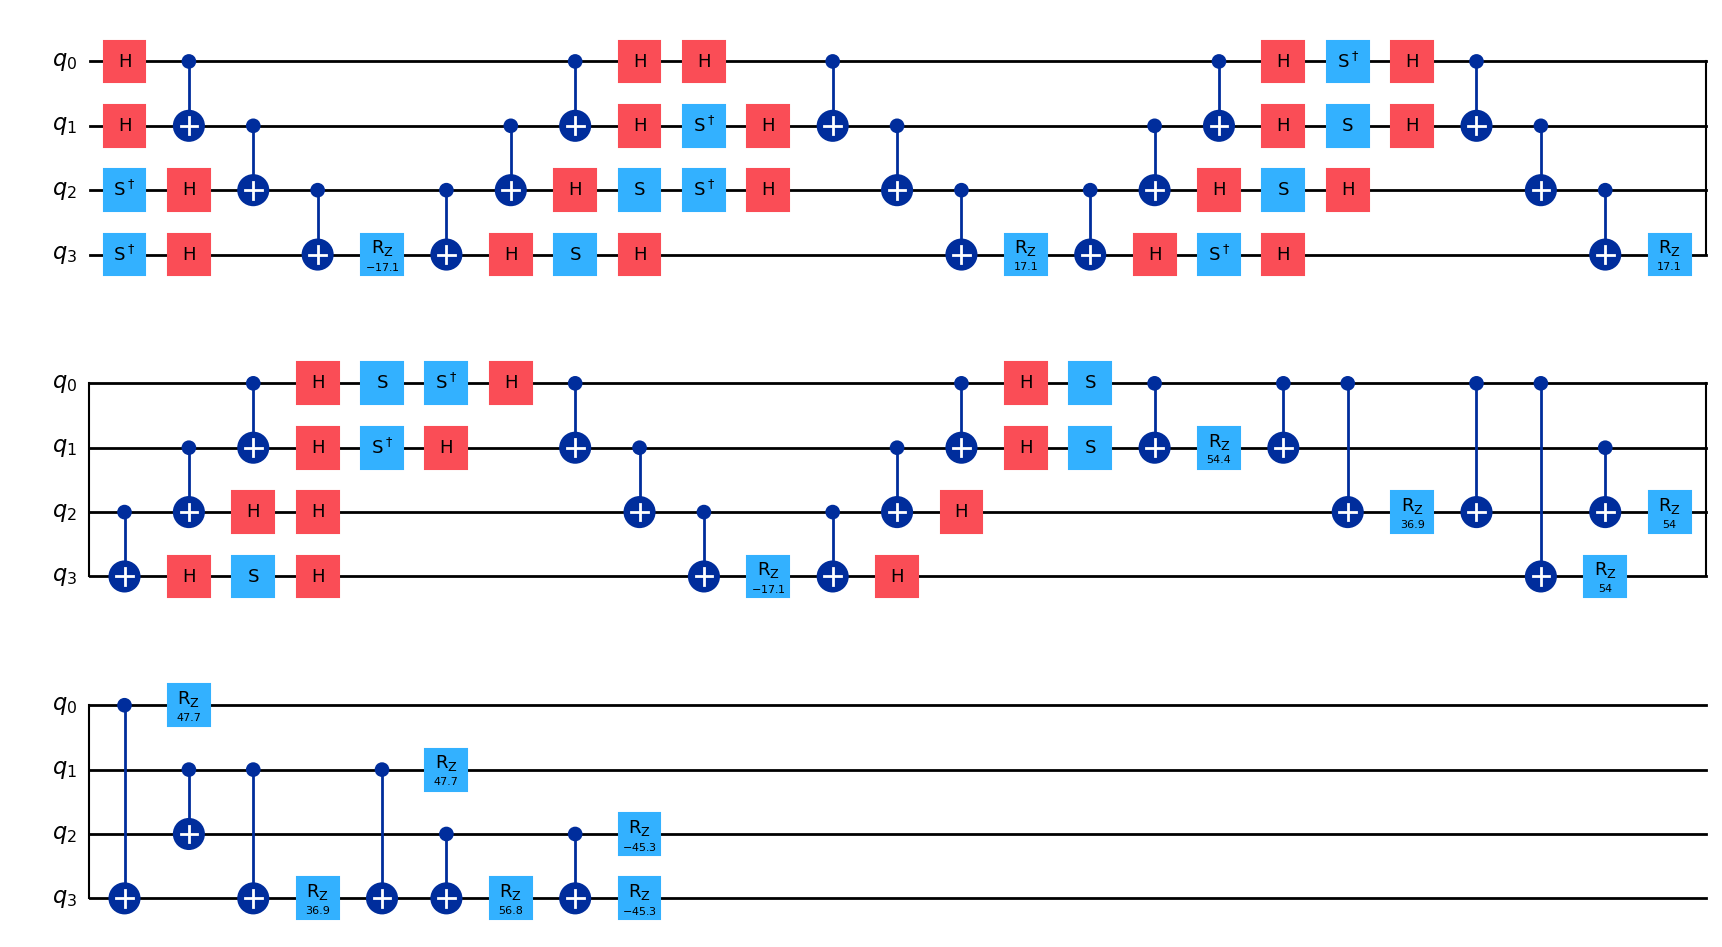

In [273]:
r=1
num_qubits = 4

U_1 = trotter_first_order(H2_q, t, r, num_qubits)  
U_1.draw("mpl")

**(iii)**

In [274]:
qc_qpe, counts, depth, time_taken,theta = run_qpe(U_1, n=8, prep_state=prep_state, shots=10000, draw_circuit=True,print_=True)

      ┌───┐┌───────────────────┐┌───────────────────┐┌───────────────────┐»
 q_0: ┤ X ├┤0                  ├┤0                  ├┤0                  ├»
      ├───┤│                   ││                   ││                   │»
 q_1: ┤ X ├┤1                  ├┤1                  ├┤1                  ├»
      └───┘│  circuit-521505^1 ││  circuit-521505^2 ││  circuit-521505^4 │»
 q_2: ─────┤2                  ├┤2                  ├┤2                  ├»
           │                   ││                   ││                   │»
 q_3: ─────┤3                  ├┤3                  ├┤3                  ├»
      ┌───┐└─────────┬─────────┘└─────────┬─────────┘└─────────┬─────────┘»
 q_4: ┤ H ├──────────■────────────────────┼────────────────────┼──────────»
      ├───┤                               │                    │          »
 q_5: ┤ H ├───────────────────────────────■────────────────────┼──────────»
      ├───┤                                                    │          »
 q_6: ┤ H ├─

In [275]:
print("Most common bitstring:", max(counts, key=counts.get))

Most common bitstring: 11101110


**(c)**

**(i)**

Code that finds $E_\text{QPE}$ automatically is useful for the next tasks.

In [276]:
def find_E(theta, Emin,Emax):
    t=2*np.pi / (Emax - Emin)
    mlow= int(np.ceil(((-Emax) * t / (2*np.pi)) - theta))
    mhigh = int(np.floor(((-Emin) * t / (2*np.pi)) - theta))
    if mlow != mhigh:
        raise ValueError("Change bounds")
    m=mhigh 
    E = -(2*np.pi / t) * (theta + m)
    return E, m 
EQPE,m=find_E(theta,Emin,Emax)
print("m =",m)
print("EQPE =",EQPE)

m = 29
EQPE = -1.0817436445255293


**(ii)**

In [277]:
print("Hartree-Fock energy is",E_uhf)

Hartree-Fock energy is -1.0661086493179366


The $E_\text{QPE}$ value found is lower than the Hartree-Fock energy, as expected for a more accurate approximation to the ground state energy.

**(iii)**

In [278]:
print("FCI energy =", EFCI)

FCI energy = -1.1011503302326187


The $E_\text{FCI}$ energy is still lower, suggesting that second-order Trotterization may improve the estimate.

In [279]:
U_2 = trotter_second_order(H2_q, t, r, num_qubits)            
qc_qpe, counts, depth, time_taken,theta = run_qpe(U_2, n=8, prep_state=prep_state, shots=1000000, draw_circuit=True,print_=True)

      ┌───┐┌───────────────────┐┌───────────────────┐┌───────────────────┐»
 q_0: ┤ X ├┤0                  ├┤0                  ├┤0                  ├»
      ├───┤│                   ││                   ││                   │»
 q_1: ┤ X ├┤1                  ├┤1                  ├┤1                  ├»
      └───┘│  circuit-523980^1 ││  circuit-523980^2 ││  circuit-523980^4 │»
 q_2: ─────┤2                  ├┤2                  ├┤2                  ├»
           │                   ││                   ││                   │»
 q_3: ─────┤3                  ├┤3                  ├┤3                  ├»
      ┌───┐└─────────┬─────────┘└─────────┬─────────┘└─────────┬─────────┘»
 q_4: ┤ H ├──────────■────────────────────┼────────────────────┼──────────»
      ├───┤                               │                    │          »
 q_5: ┤ H ├───────────────────────────────■────────────────────┼──────────»
      ├───┤                                                    │          »
 q_6: ┤ H ├─

In [280]:
EQPE,m=find_E(theta,Emin,Emax)
print("m =",m)
print("EQPE =",EQPE)

m = 30
EQPE = -1.0961443038496748


An improvement is observed, however this is somewhat unrealistic since the calculation uses a noise free simulator. On real quantum hardware, the increased circuit depth would generally introduce more noise. The printed depths of the two QPE circuits are identical because Qiskit treats the time evolution unitaries as single gates. The actual depth difference between the first-order and second-order time evolution circuits is shown below.

In [281]:
print("First-order depth:",U_1.depth())
print("Second-order depth:",U_2.depth())

First-order depth: 57
Second-order depth: 114


**(d)**

**(i)**

Included above.

**(ii)**

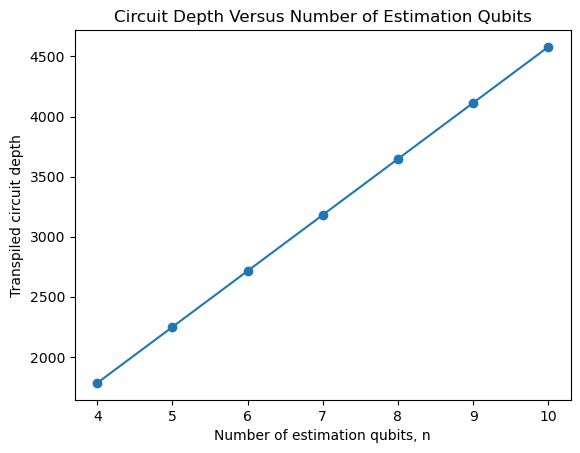

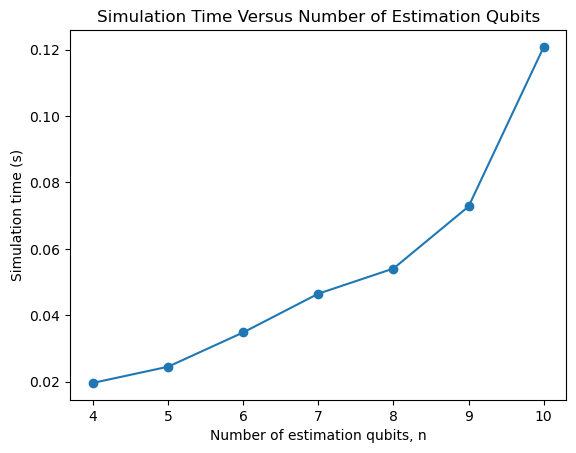

In [286]:
depths = []
times = []

n_list = list(range(4, 11))

for n in n_list:
    mult_run_time=[]
    for r in range(100):#take average time over many runs to reduce time uncertainty 
        qc_qpe, counts, depth, time_taken,theta = run_qpe(U_1, n=n, prep_state=prep_state, shots=10000, draw_circuit=False)
        mult_run_time.append(time_taken)
    depths.append(depth)
    times.append(np.mean(mult_run_time))

plt.figure()
plt.plot(n_list, depths, marker="o")
plt.xlabel("Number of estimation qubits, n")
plt.ylabel("Transpiled circuit depth")
plt.title("Circuit Depth Versus Number of Estimation Qubits")
plt.show()

plt.figure()
plt.plot(n_list, times, marker="o")
plt.xlabel("Number of estimation qubits, n")
plt.ylabel("Simulation time (s)")
plt.title("Simulation Time Versus Number of Estimation Qubits")
plt.show()

Circuit depth increases approximately linearly with $n$. Simulation time also increases with $n$, but more rapidly. This is because a statevector simulation of $N$ qubits stores $2^N$ amplitudes, so the memory and computational cost grow exponentially with the total qubit number.

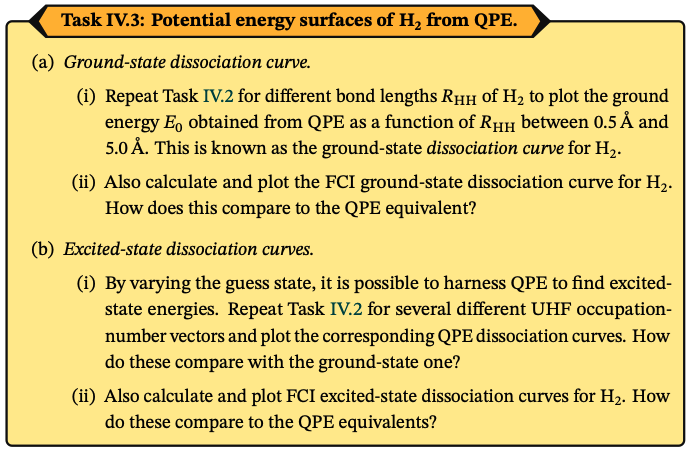

In [111]:
Image('4_3.png')

**(a)**

First compare the $H_2$ Hamiltonian from the written functions with the PySCF values for extreme $R_{HH}$ values.

In [154]:
atom = """
H 0 0 0
H 0 0 0.5
"""
print("0.5 Angstrom")
H = second_quantized_hamiltonian(atom=atom, basis="sto-3g")
H_q = jw_transform(H)
print("Written\n")
print(H_q)
mol = MolecularData(atom, basis, multiplicity=1)
mol = run_pyscf(mol)

H_ref = jordan_wigner(mol.get_molecular_hamiltonian()) 
print("\nPySCF\n")
print(H_ref)

0.5 Angstrom
Written

(0.3798313517809502+0j) [] +
(-0.04221755692243371+0j) [X0 X1 Y2 Y3] +
(0.04221755692243371+0j) [X0 Y1 Y2 X3] +
(0.04221755692243371+0j) [Y0 X1 X2 Y3] +
(-0.04221755692243371+0j) [Y0 Y1 X2 X3] +
(0.21393531024521223+0j) [Z0] +
(0.17992650976405983+0j) [Z0 Z1] +
(0.13459240346368884+0j) [Z0 Z2] +
(0.1768099603861225+0j) [Z0 Z3] +
(0.21393531024521223+0j) [Z1] +
(0.1768099603861225+0j) [Z1 Z2] +
(0.13459240346368884+0j) [Z1 Z3] +
(-0.3691443152437638+0j) [Z2] +
(0.1862098425924703+0j) [Z2 Z3] +
(-0.36914431524376384+0j) [Z3]

PySCF

0.3798313517809503 [] +
-0.042217556922433716 [X0 X1 Y2 Y3] +
0.042217556922433716 [X0 Y1 Y2 X3] +
0.042217556922433716 [Y0 X1 X2 Y3] +
-0.042217556922433716 [Y0 Y1 X2 X3] +
0.21393531024521256 [Z0] +
0.1799265097640598 [Z0 Z1] +
0.13459240346368873 [Z0 Z2] +
0.17680996038612246 [Z0 Z3] +
0.21393531024521256 [Z1] +
0.17680996038612246 [Z1 Z2] +
0.13459240346368873 [Z1 Z3] +
-0.3691443152437641 [Z2] +
0.18620984259247086 [Z2 Z3] +
-0.3691

In [155]:
atom = """
H 0 0 0
H 0 0 5
"""
print("5 Angstrom")
H = second_quantized_hamiltonian(atom=atom, basis="sto-3g")
H_q = jw_transform(H)
print("Written\n")
print(H_q)
mol = MolecularData(atom, basis, multiplicity=1)
mol = run_pyscf(mol)

H_ref = jordan_wigner(mol.get_molecular_hamiltonian()) 
print("\nPySCF\n")
print(H_ref)

5 Angstrom
Written

(-0.5458607027942335+0j) [] +
(-0.08359631370988604+0j) [X0 X1 Y2 Y3] +
(0.08359631370988604+0j) [X0 Y1 Y2 X3] +
(0.08359631370988604+0j) [Y0 X1 X2 Y3] +
(-0.08359631370988604+0j) [Y0 Y1 X2 X3] +
(0.03970104575308903+0j) [Z0] +
(0.11004294256569613+0j) [Z0 Z1] +
(0.026458859479781632+0j) [Z0 Z2] +
(0.11005517318966766+0j) [Z0 Z3] +
(0.039701045753089026+0j) [Z1] +
(0.11005517318966766+0j) [Z1 Z2] +
(0.02645885947978162+0j) [Z1 Z3] +
(0.03957781813360586+0j) [Z2] +
(0.11006740930024875+0j) [Z2 Z3] +
(0.039577818133605724+0j) [Z3]

PySCF

-0.5458607027942334 [] +
-0.08359631370988599 [X0 X1 Y2 Y3] +
0.08359631370988599 [X0 Y1 Y2 X3] +
0.08359631370988599 [Y0 X1 X2 Y3] +
-0.08359631370988599 [Y0 Y1 X2 X3] +
0.039701045753089165 [Z0] +
0.11004294256569604 [Z0 Z1] +
0.02645885947978159 [Z0 Z2] +
0.1100551731896676 [Z0 Z3] +
0.03970104575308918 [Z1] +
0.1100551731896676 [Z1 Z2] +
0.02645885947978159 [Z1 Z3] +
0.03957781813360589 [Z2] +
0.11006740930024869 [Z2 Z3] +
0.0395

Good agreement.

**(i)**

In [181]:
def E0calc(R, prep, n, basis="sto-3g", shots=200000, r=1, trotter_order=1):
    #geometry
    atom = f"""
    H 0 0 0
    H 0 0 {R}
    """

    #E UHF
    C_a, C_b, labels, (occ_a, occ_b), E_uhf = uhf_mos(atom, basis)

    #prepare state, generalised for part b
    ps = occupation_to_paulistring(prep)
    prep_state = QuantumCircuit(4)
    append_pauli(prep_state, ps)

    #FCI
    mol = gto.M(atom=atom, basis=basis,unit="Angstrom",charge=0,spin=0,verbose=0)
    mf = scf.UHF(mol).run() #unrestricted?

    cisolver = fci.FCI(mol, mf.mo_coeff)
    FCI=cisolver.kernel()[0]
    # bounds
    Emin = 1.01*FCI
    Emax = E_uhf
    t = 2*np.pi / (Emax - Emin)

    H = second_quantized_hamiltonian(atom=atom, basis=basis)
    H_q = jw_transform(H)    
    H2_q=ps_convert(H_q)
    
    num_qubits = 4
    if trotter_order == 1:
        U = trotter_first_order(H2_q, t, r, num_qubits)
    else:
        U = trotter_second_order(H2_q, t, r, num_qubits)

    #QPE
    qc_qpe, counts, depth, time_taken,theta = run_qpe(U, n=n, prep_state=prep_state, shots=shots, draw_circuit=False)

    # E0
    E0, m = find_E(theta, Emin, Emax)


    return E0, FCI


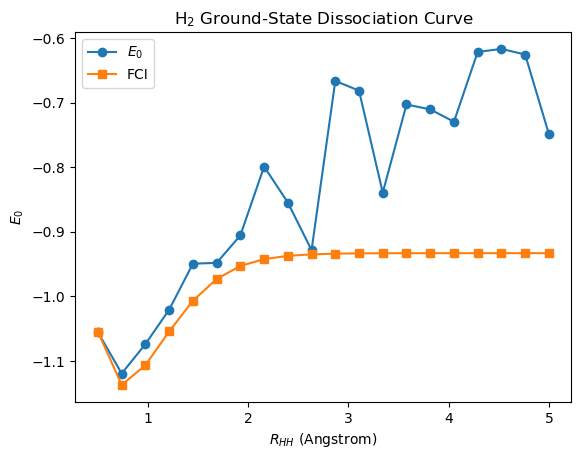

In [182]:
R_list = np.linspace(0.5, 5.0, 20)
k_uhf = (1, 1, 0, 0)
E0s = []
FCIs = []  
for R in R_list:
    E0,FCI=E0calc(R,k_uhf, n=8, basis="sto-3g", shots=200000, r=20, trotter_order=2)
    E0s.append(E0)
    FCIs.append(FCI)


plt.figure()
plt.plot(R_list, E0s, marker="o", label=r"$E_0$")
plt.plot(R_list, FCIs, marker="s", label="FCI")
plt.xlabel(r"$R_{HH}$ (Angstrom)")
plt.ylabel(r"$E_0$")
plt.title("H$_2$ Ground-State Dissociation Curve")
plt.legend()
plt.show()

HF is a variational single determinant approximation that is often a good guess near equilibrium, but it misses strong correlation at stretched bonds [9]. FCI includes all determinants in the chosen basis, so it is the benchmark dissociation curve. QPE matches FCI well when the UHF guess has good overlap, which can be seen for low $R_{HH}$, but there is less agreement at large $R_{HH}$ because there is less overlap.

**(b)**

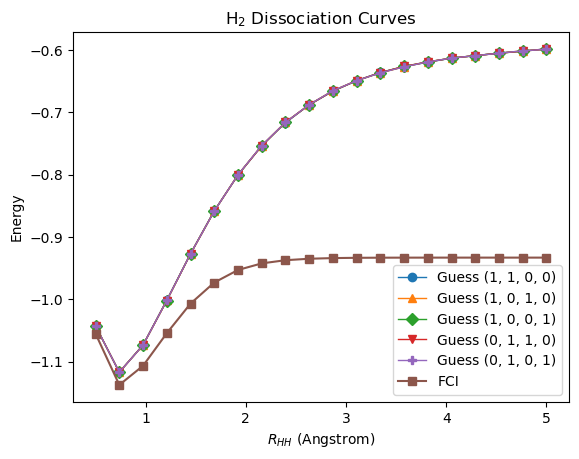

In [158]:
occ_list = [(1,1,0,0),(1,0,1,0),(1,0,0,1),(0,1,1,0),(0,1,0,1)]
markers = ["o", "^", "D", "v", "P"] # lots of overlapping
curves = {}
for occ in occ_list:
    E0s = []
    FCIs = []  
    for R in R_list:
        E0,FCI=E0calc(R,occ, n=8, basis="sto-3g", shots=200000, r=20, trotter_order=2)
        E0s.append(E0)
        FCIs.append(FCI)
    curves[occ] = E0s

plt.figure()
for i, occ in enumerate(occ_list):
    plt.plot(R_list, curves[occ], marker=markers[i],linewidth=1, label=f"Guess {occ}")

plt.plot(R_list, FCIs, marker="s", label="FCI")

plt.xlabel(r"$R_{HH}$ (Angstrom)")
plt.ylabel("Energy")
plt.title("H$_2$ Dissociation Curves")
plt.legend()
plt.show()

Expect that the ground-state curve is lower at each point than for each of the guesses, however as can be seen they all seem to match exactly. This makes sense from the code as the values are within a $0.001$ bound of the E$_{\text{UHF}}$ values. Since the curves are the same as for the ground state, the same comment as above stands.

### References

[1]    Huynh, Bang. Quantum Computing for Quantum Chemistry. Laboratory manual, University of Oxford, September 2025.

[2]    Young, David C. _Computational Chemistry: A Practical Guide for Applying Techniques to Real World Problems_. Wiley Interscience, 2001.

[3]    _PySCF: Quickstart_. PySCF.org. https://pyscf.org/quickstart.html. 

[4]    Schulz, H. Basis Sets in Quantum Chemistry. Lecture notes, University of Rostock https://www.schulz.chemie.uni-rostock.de/storages/uni-rostock/Alle_MNF/Chemie_Schulz/Computerchemie_3/basis_sets.pdf.

[5]    _OpenFermion-PySCF Demo_. Quantumlib. https://github.com/quantumlib/OpenFermion-PySCF/blob/main/examples/openfermionpyscf_demo.ipynb. 

[6]    _Superposition with Qiskit_. IBM Quantum Learning. https://quantum.cloud.ibm.com/learning/en/modules/quantum-mechanics/superposition-with-qiskit.

[7]    _NumPy Data types_. NumPy Developers Documentation. https://numpy.org/devdocs/user/basics.types.html.

[8]    _Gibibyte (GiB)_. National Institute of Standards and Technology (NIST) Computer Security Resource Center Glossary. https://csrc.nist.gov/glossary/term/gibibyte.

[9]    Tew, David P. TCC Electronic Structure Module: L2 Hartree-Fock Theory. Lecture notes, University of Oxford, 2021

[10]   Tew, David P. TCC Electronic Structure Module: L3: Configuration Interaction Theory. Lecture notes, University of Oxford, 2021

[11]   _Configuration Interaction (CI) - User Guide_. PySCF.org. https://pyscf.org/user/ci.html.
